# **The project focuses on customer churn prediction in the telecommunications industry. Customer acquisition is expensive, making customer retention a critical business objective.**

# **Business Objective**

**The main objective is to identify customers who are likely to churn and enable proactive retention strategies before they leave.**

**Hypothesis 1**

Customers with aging devices are more likely to churn because outdated equipment may reduce customer satisfaction.

**Hypothesis 2**

Customers with lower tenure are more likely to churn because they have not yet developed long-term loyalty.

**Hypothesis 3**

Customers experiencing network-related issues (dropped, blocked, or unanswered calls) are at higher risk of churn.

**Hypothesis 4**

Changes in customer usage and revenue patterns may indicate disengagement before churn occurs.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Final Assignment/telecom


/content/drive/.shortcut-targets-by-id/122ym61Blotm6Lg7OgOx5-m4kj-RbcvnB/Final Assignment/telecom


In [3]:
!pip install boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 166.2 kB/s eta 0:00:00


In [4]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.5 MB/s eta 0:00:00


In [5]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.2 MB/s eta 0:00:00


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score,accuracy_score,precision_recall_curve,fbeta_score, classification_report, confusion_matrix,ConfusionMatrixDisplay,f1_score
from xgboost import XGBClassifier
from boruta import BorutaPy
import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,PowerTransformer
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


In [7]:
SEED=42

In [8]:
df= pd.read_csv("/content/drive/MyDrive/Final Assignment/telecom/Client.csv")
dff= pd.read_csv("/content/drive/MyDrive/Final Assignment/telecom/Record.csv")

In [9]:
data=df.merge(dff,on='Customer_ID',how='inner')


# **EDA**

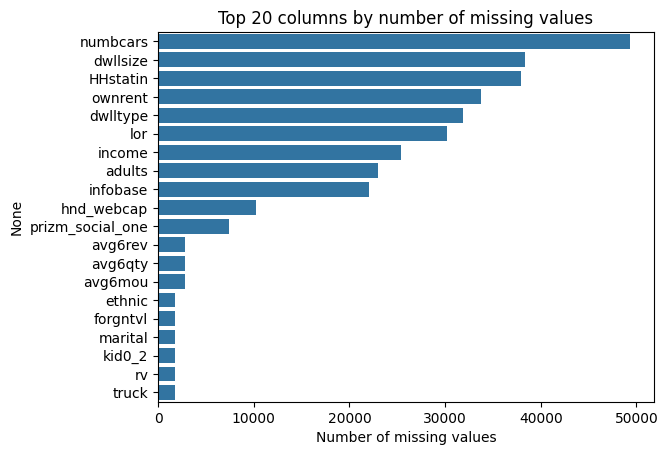

In [10]:
missing_counts = data.isna().sum()

top_missing = missing_counts.sort_values(ascending=False).head(20)

sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

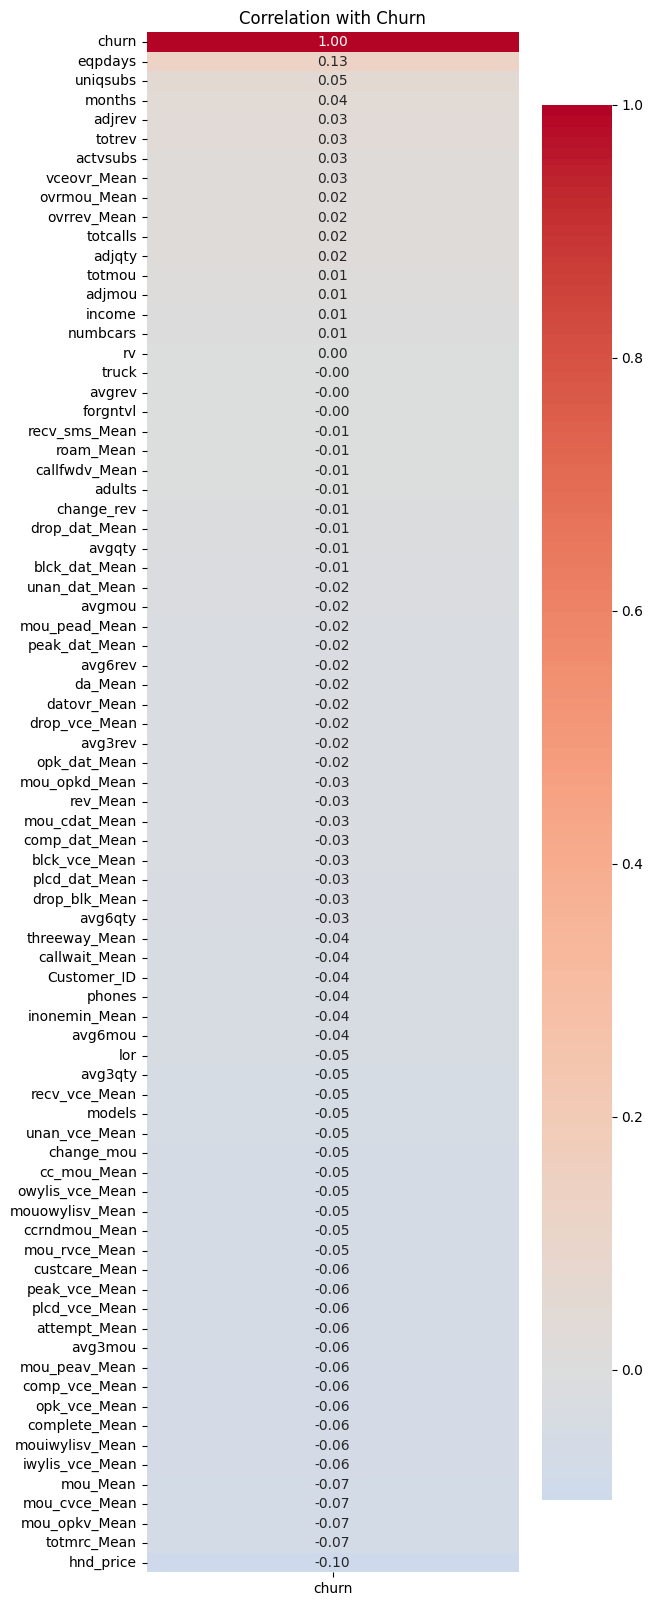

In [11]:
corr_with_churn = (
    data.select_dtypes(include='number')
        .corr('spearman')[['churn']]
        .sort_values(by='churn', ascending=False)
)

plt.figure(figsize=(6, 20))
sns.heatmap(
    corr_with_churn,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Correlation with Churn')
plt.show()

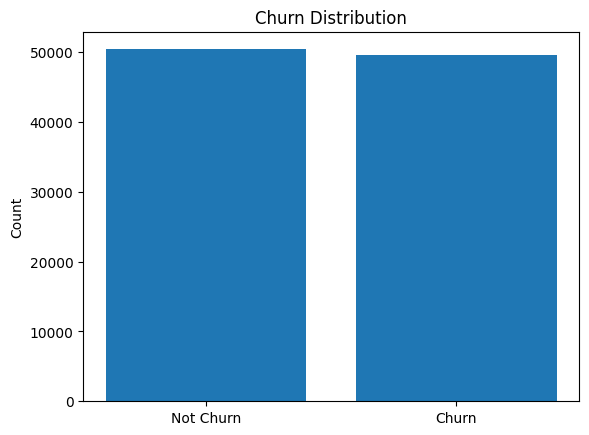

In [76]:
churn_counts = data['churn'].value_counts()

plt.bar(churn_counts.index, churn_counts.values)
plt.xticks([0, 1], ['Not Churn', 'Churn'])
plt.ylabel('Count')
plt.title('Churn Distribution')
plt.show()

Mean equipment age (stayed):  363.3 days
Mean equipment age (churned): 421.1 days


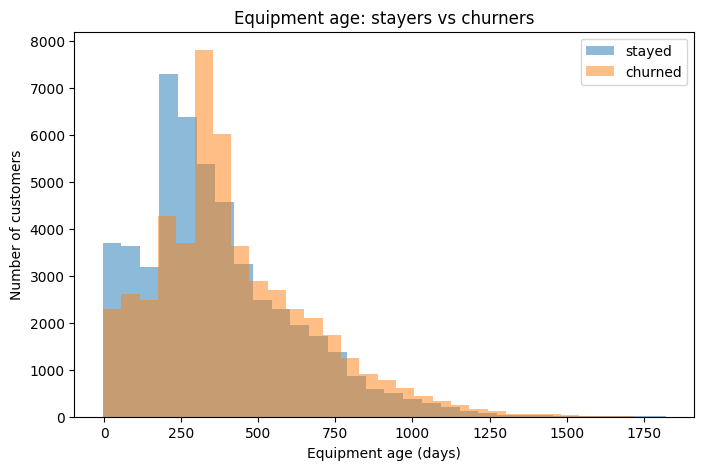

In [77]:
stayed = data[data['churn'] == 0]['eqpdays']
churned = data[data['churn'] == 1]['eqpdays']

print(f'Mean equipment age (stayed):  {stayed.mean():.1f} days')
print(f'Mean equipment age (churned): {churned.mean():.1f} days')

plt.figure(figsize=(8, 5))
plt.hist(stayed, bins=30, alpha=0.5, label='stayed')
plt.hist(churned, bins=30, alpha=0.5, label='churned')
plt.xlabel('Equipment age (days)')
plt.ylabel('Number of customers')
plt.title('Equipment age: stayers vs churners')
plt.legend()
plt.show()

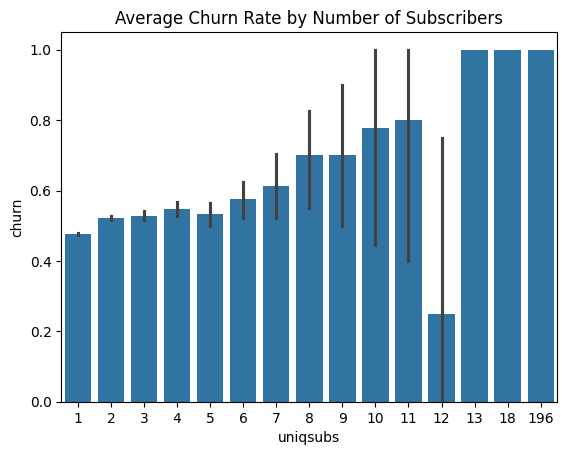

In [78]:
sns.barplot(
    data=data,
    x='uniqsubs',
    y='churn'
)

plt.title('Average Churn Rate by Number of Subscribers')
plt.show()

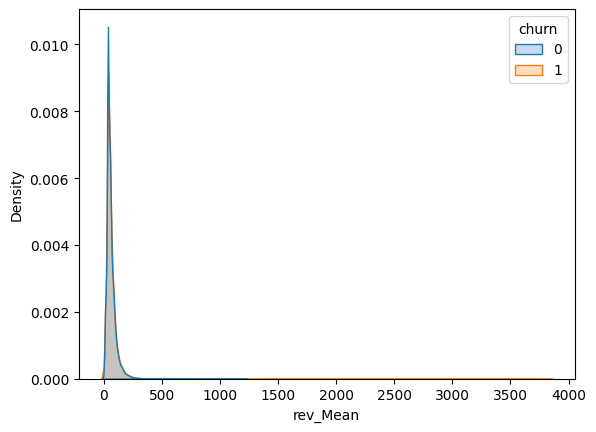

In [79]:
sns.kdeplot(
    data=data,
    x='rev_Mean',
    hue='churn',
    fill=True
)
plt.show()

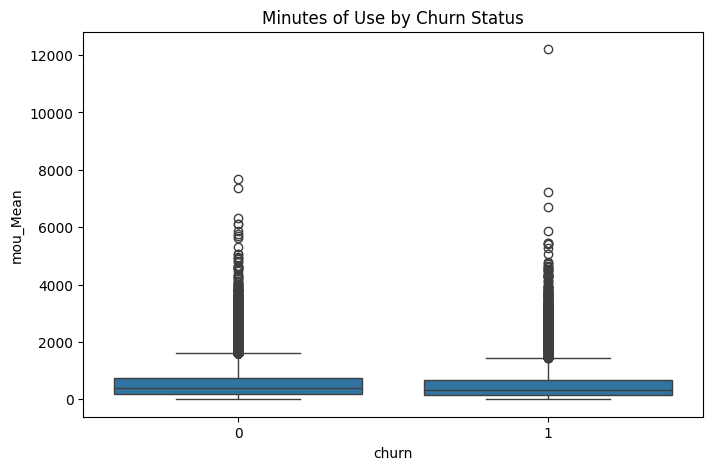

In [80]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x='churn',
    y='mou_Mean'
)

plt.title('Minutes of Use by Churn Status')
plt.show()

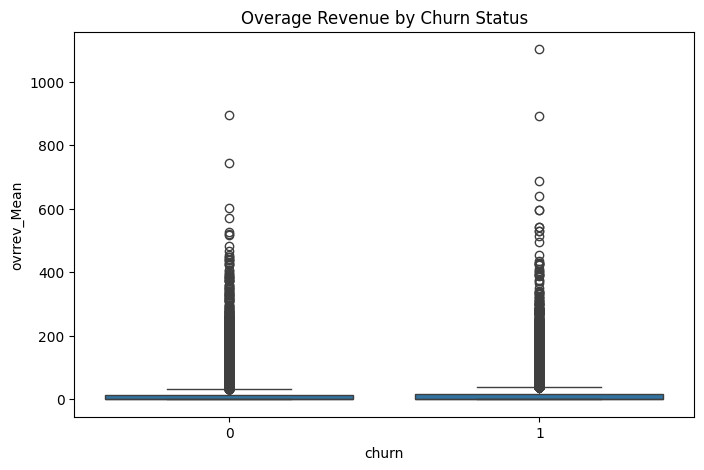

In [81]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x='churn',
    y='ovrrev_Mean'
)

plt.title('Overage Revenue by Churn Status')
plt.show()

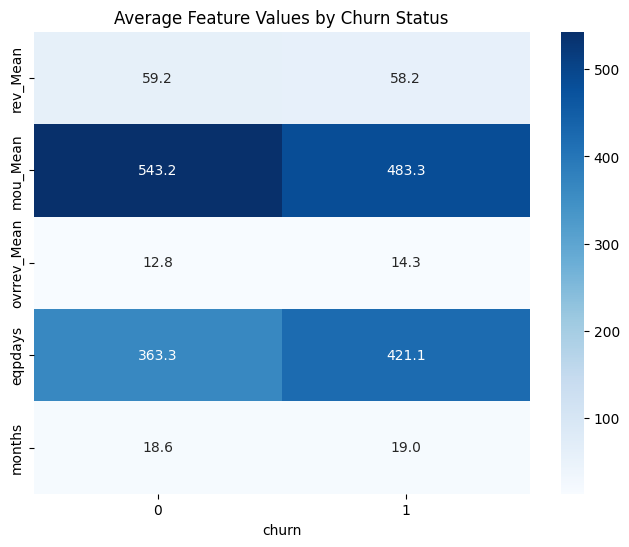

In [82]:
cols = [
    'rev_Mean',
    'mou_Mean',
    'ovrrev_Mean',
    'eqpdays',
    'months'
]

data.groupby('churn')[cols].mean().T

plt.figure(figsize=(8,6))

sns.heatmap(
    data.groupby('churn')[cols].mean().T,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Average Feature Values by Churn Status')
plt.show()

In [12]:
numerical_col_ = data.select_dtypes(include='number').columns.to_list()


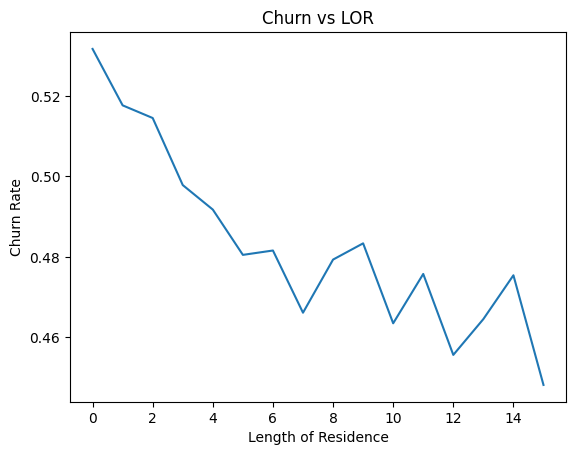

In [13]:
lor_churn = data.groupby('lor')['churn'].mean()

plt.plot(lor_churn.index, lor_churn.values)
plt.xlabel('Length of Residence')
plt.ylabel('Churn Rate')
plt.title('Churn vs LOR')
plt.show()

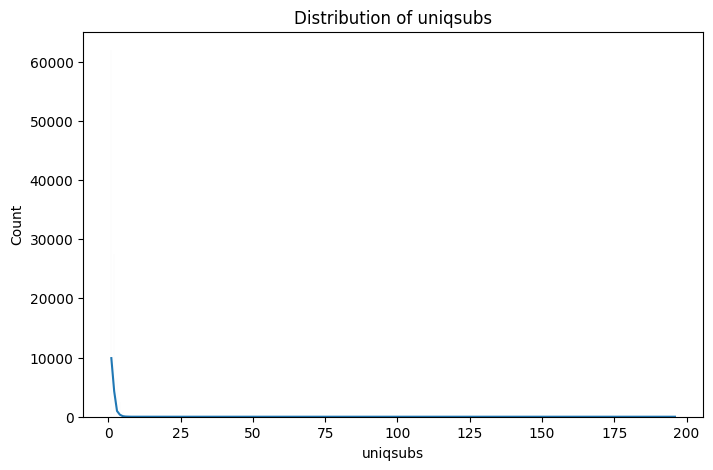

Skewness: 60.519797494375645
**********


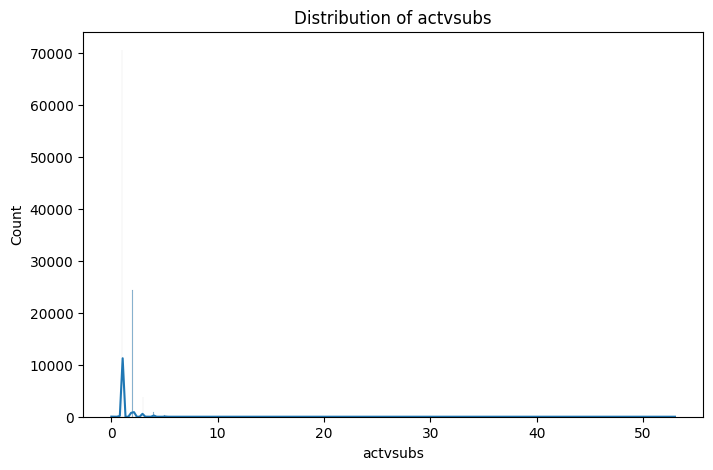

Skewness: 6.867448177482075
**********


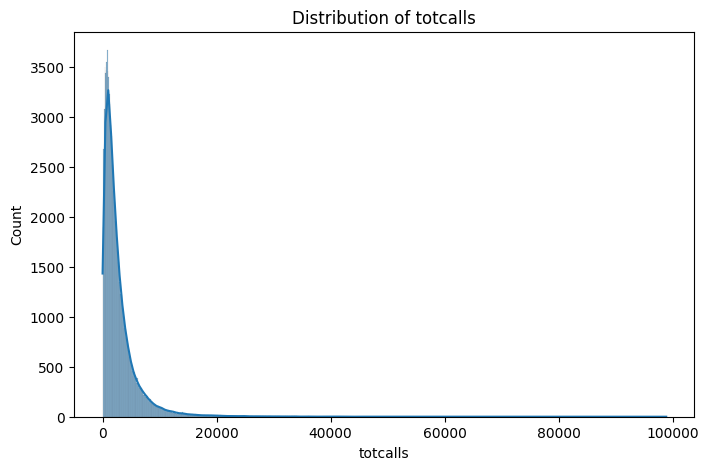

Skewness: 6.018164164972117
**********


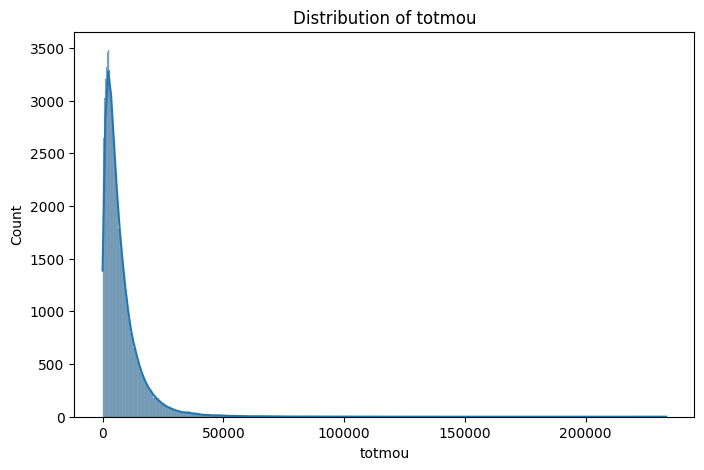

Skewness: 4.400934090516003
**********


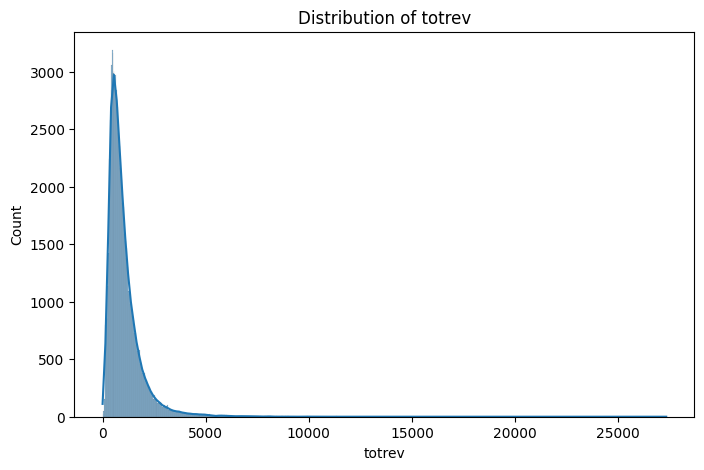

Skewness: 3.818583579267274
**********


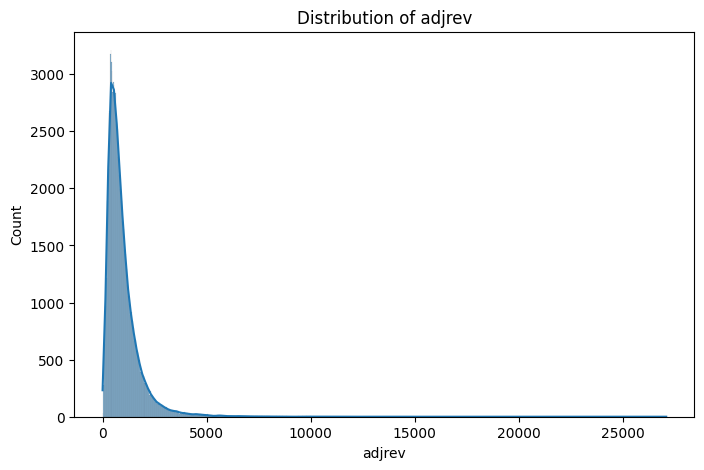

Skewness: 3.833840051791096
**********


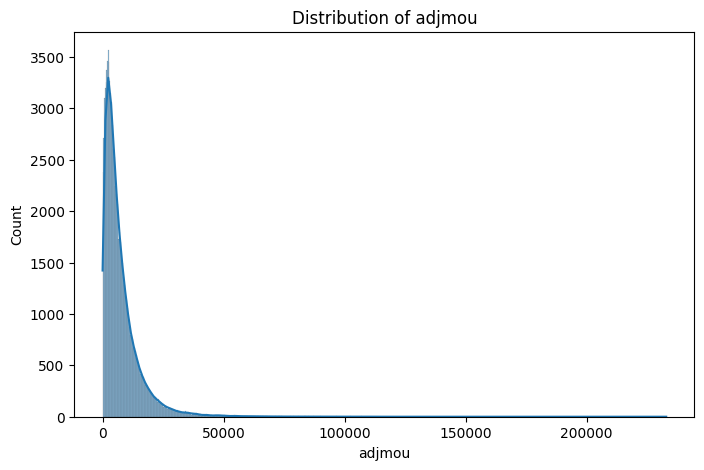

Skewness: 4.423042404630199
**********


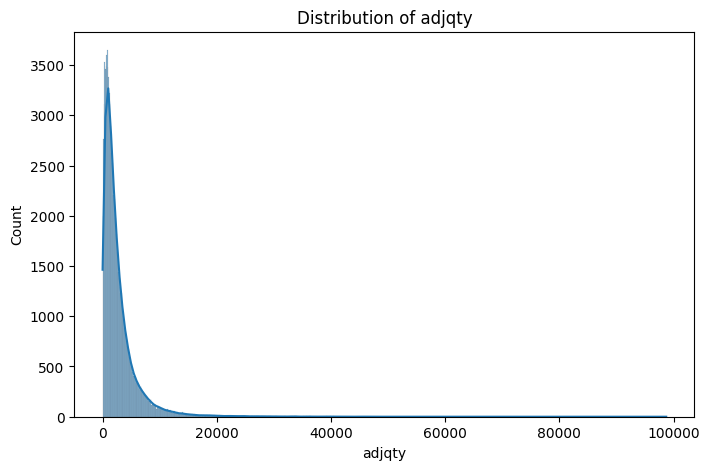

Skewness: 6.050154075899863
**********


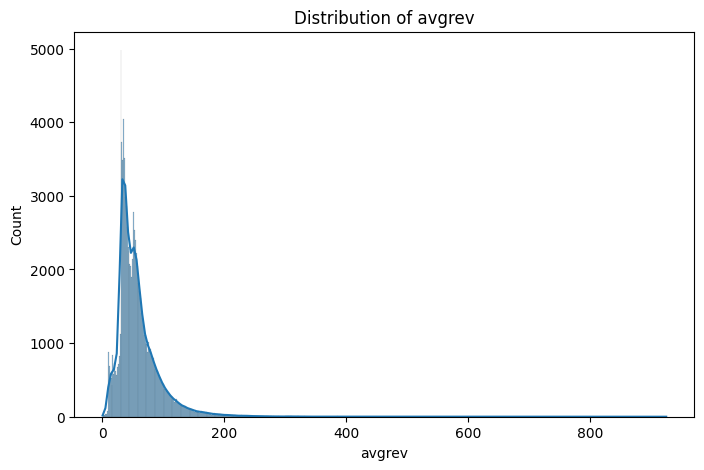

Skewness: 3.2077484112043413
**********


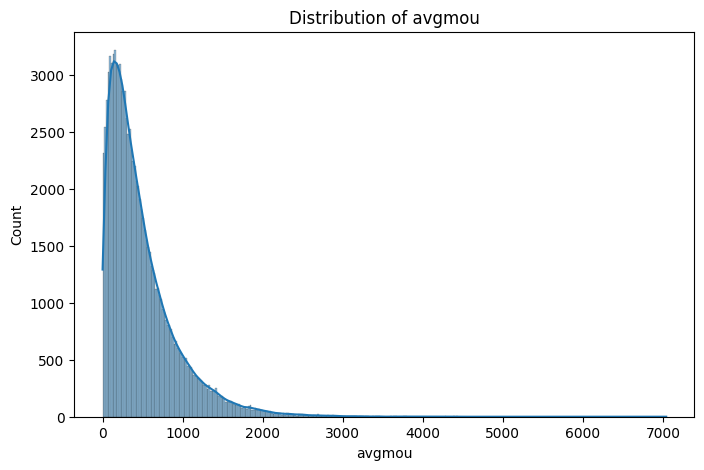

Skewness: 2.017084476325279
**********


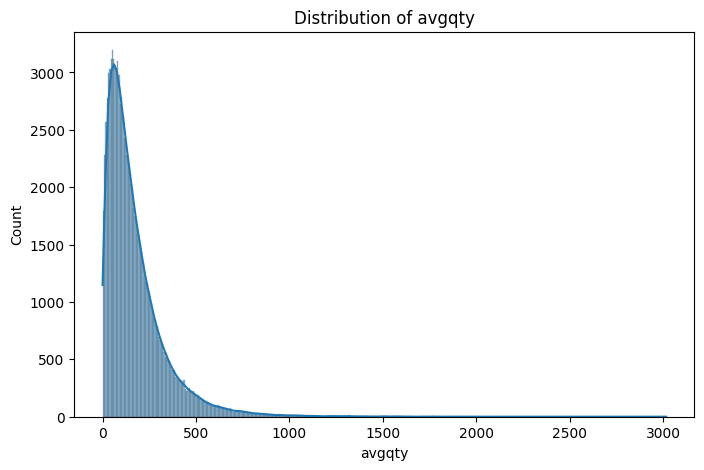

Skewness: 2.902884873179485
**********


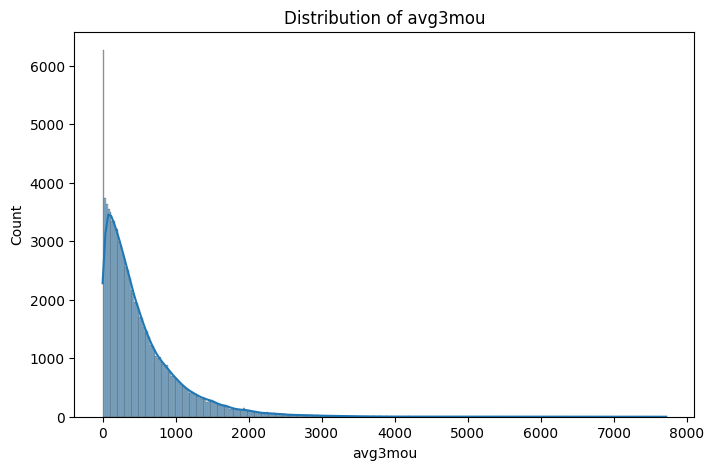

Skewness: 2.2314170479780975
**********


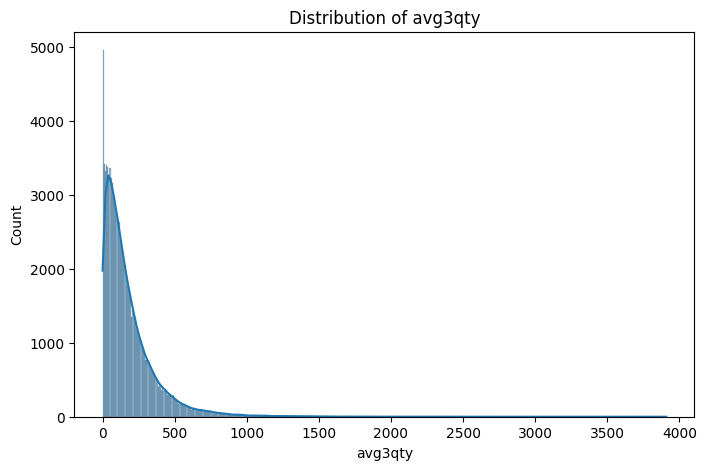

Skewness: 3.073586003727004
**********


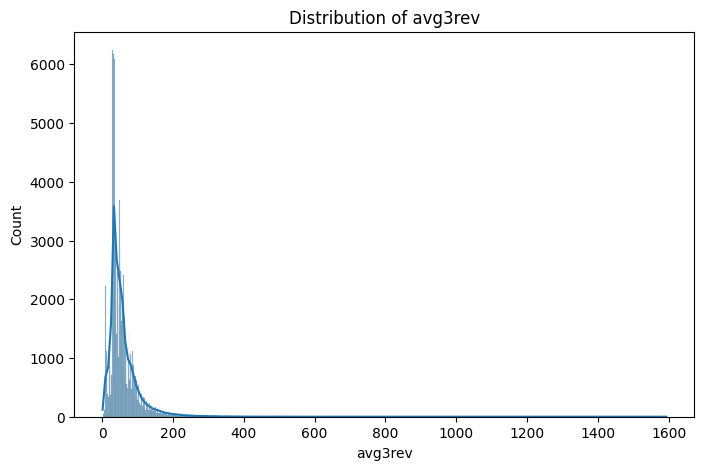

Skewness: 4.526901556778156
**********


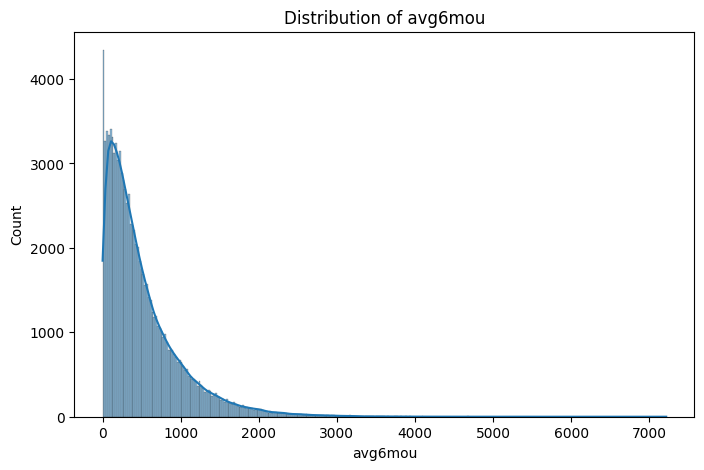

Skewness: 2.0865719054656595
**********


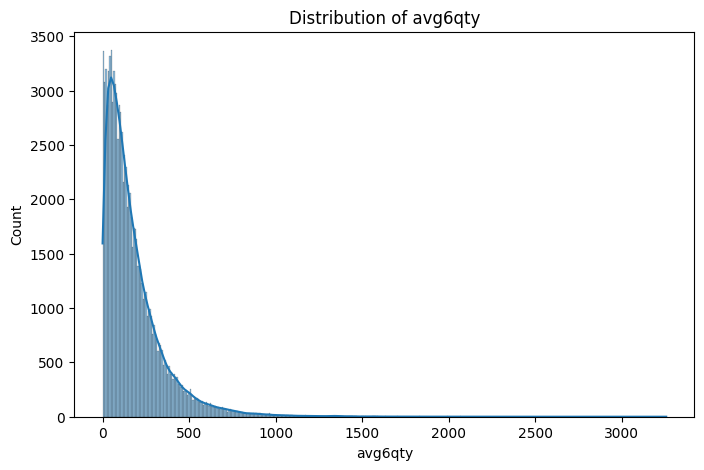

Skewness: 2.9563622654690307
**********


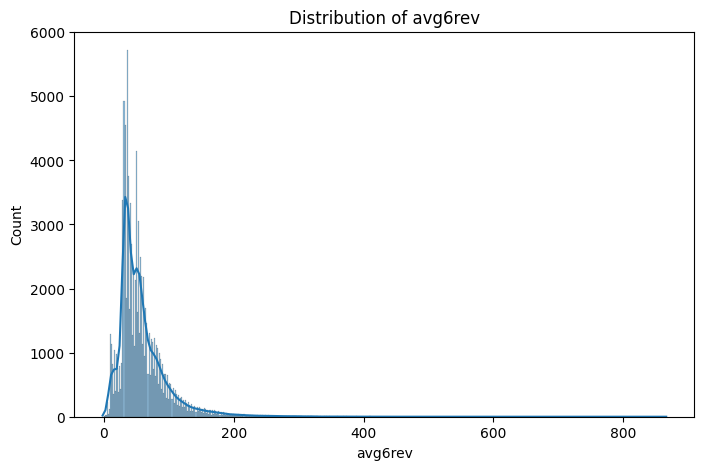

Skewness: 3.4879592569947895
**********


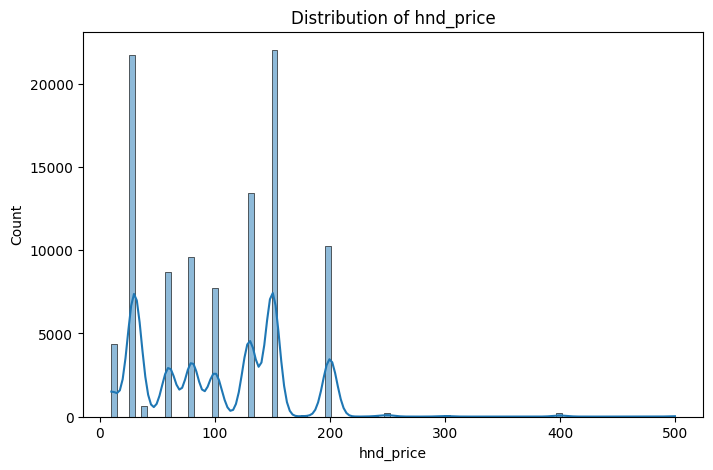

Skewness: 0.47900814802669023
**********


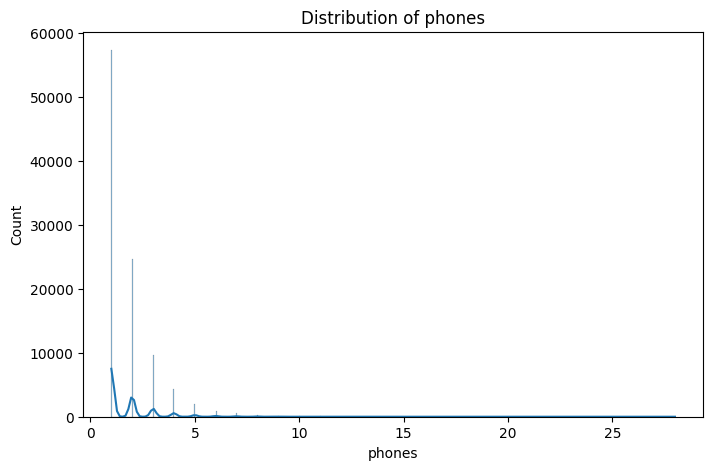

Skewness: 3.281307107490765
**********


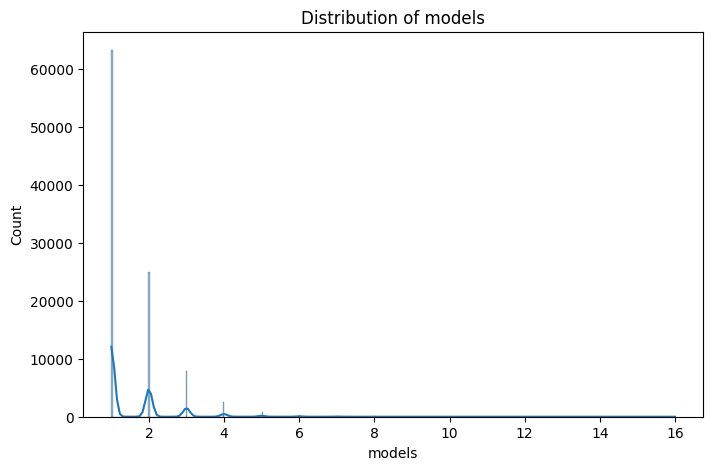

Skewness: 2.431108503792723
**********


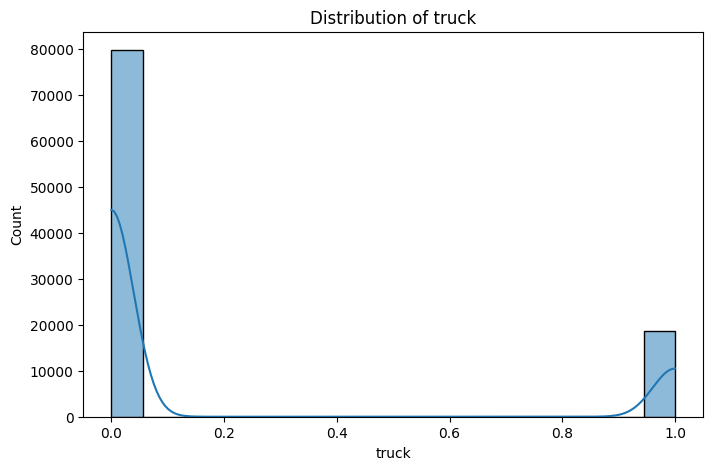

Skewness: 1.590247961395764
**********


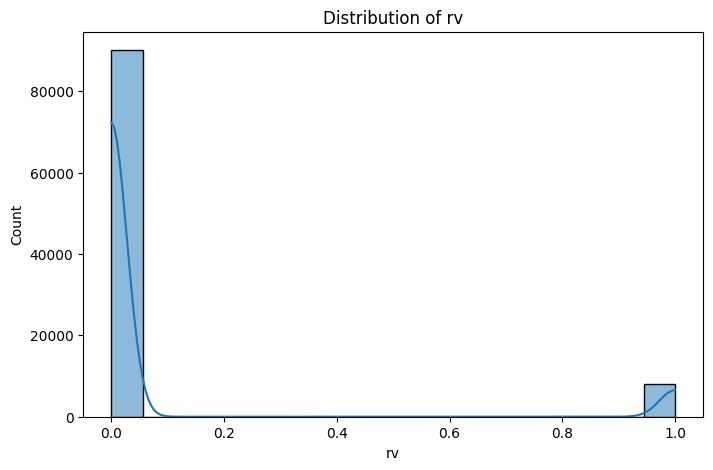

Skewness: 3.033104265542613
**********


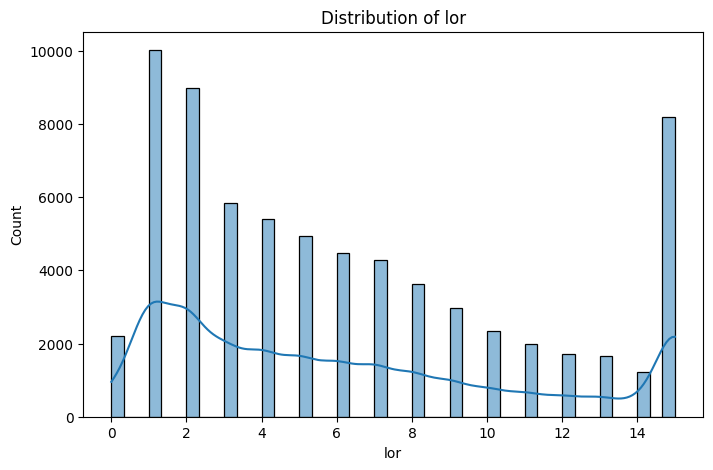

Skewness: 0.6330221998249549
**********


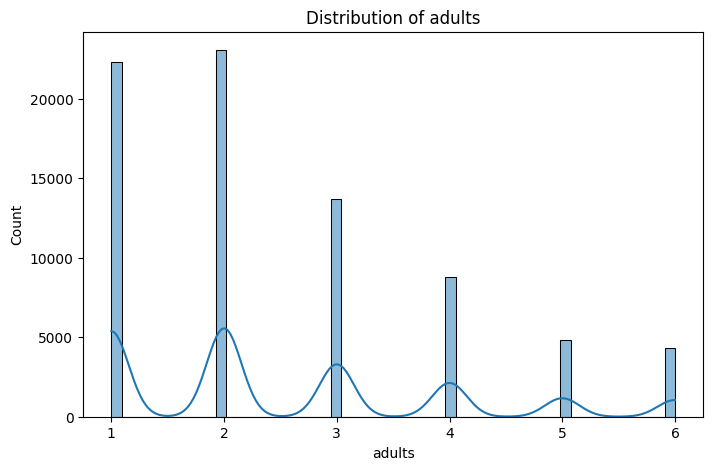

Skewness: 0.8484120813025928
**********


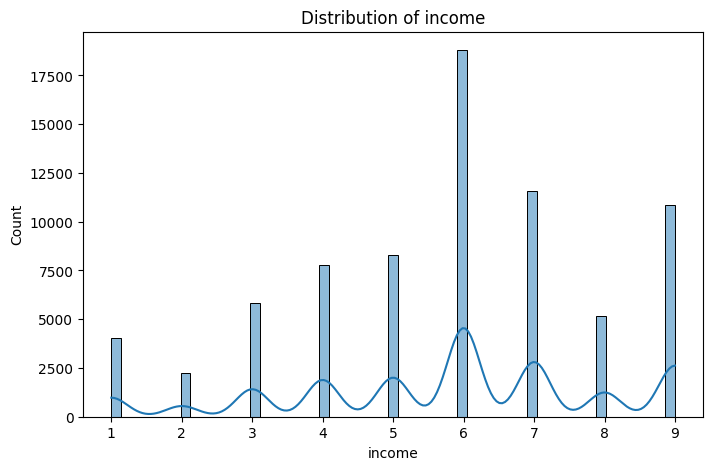

Skewness: -0.386933466796976
**********


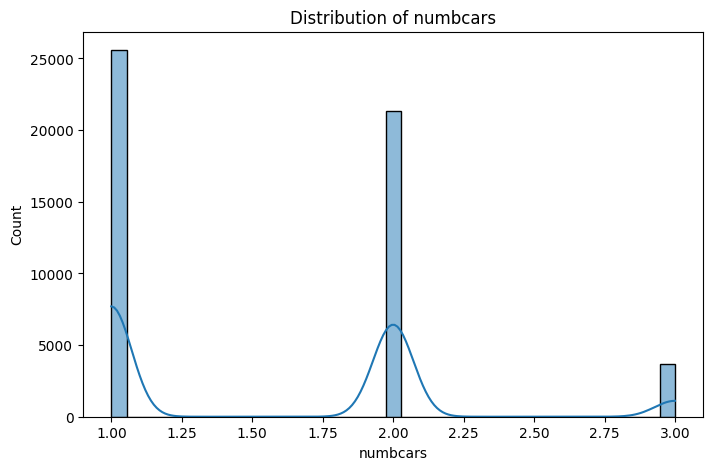

Skewness: 0.6372934893898995
**********


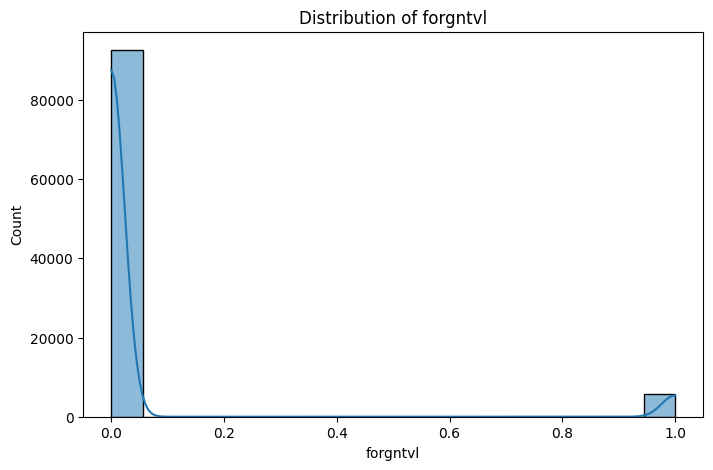

Skewness: 3.7829958116889797
**********


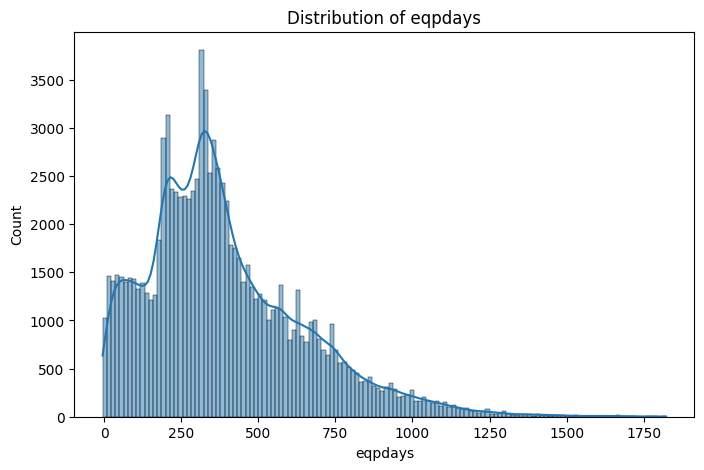

Skewness: 1.043996744212559
**********


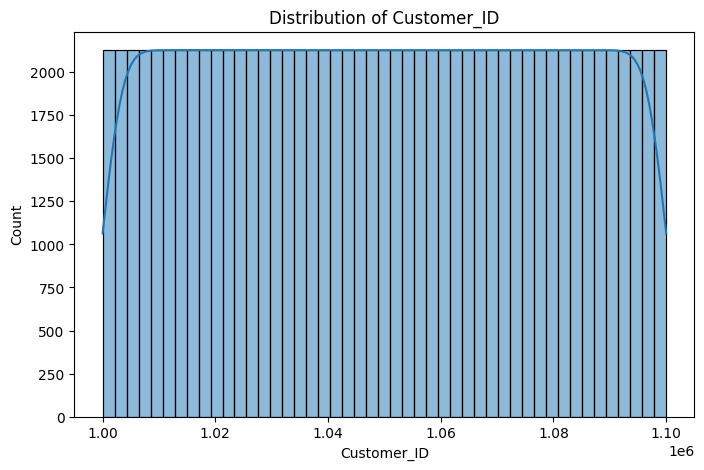

Skewness: 0.0
**********


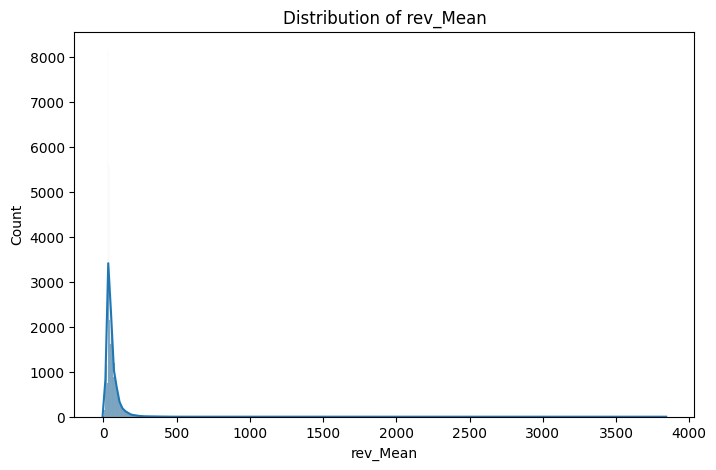

Skewness: 9.152623976221875
**********


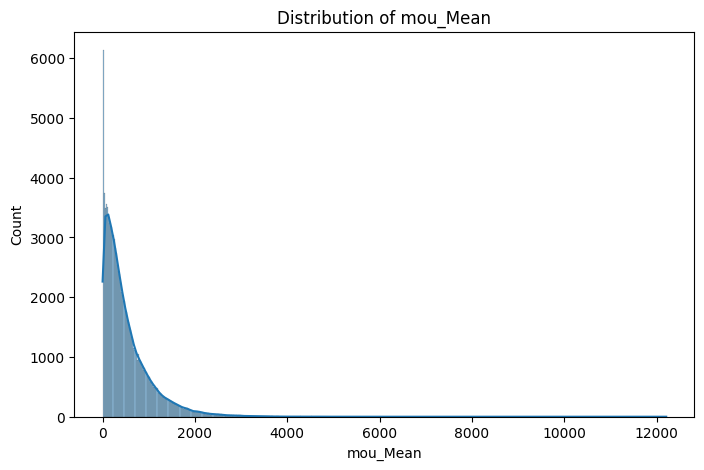

Skewness: 2.3143698881483608
**********


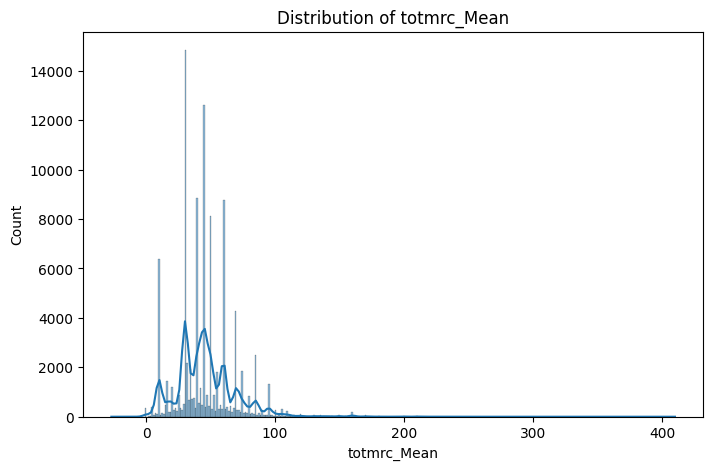

Skewness: 1.6416961270821315
**********


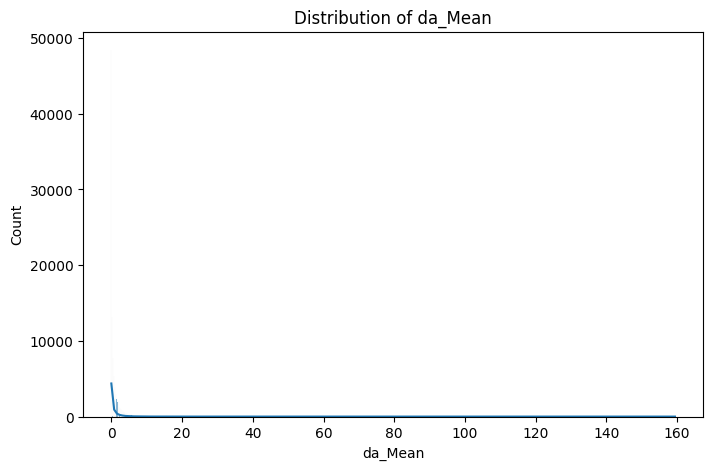

Skewness: 10.81306499083376
**********


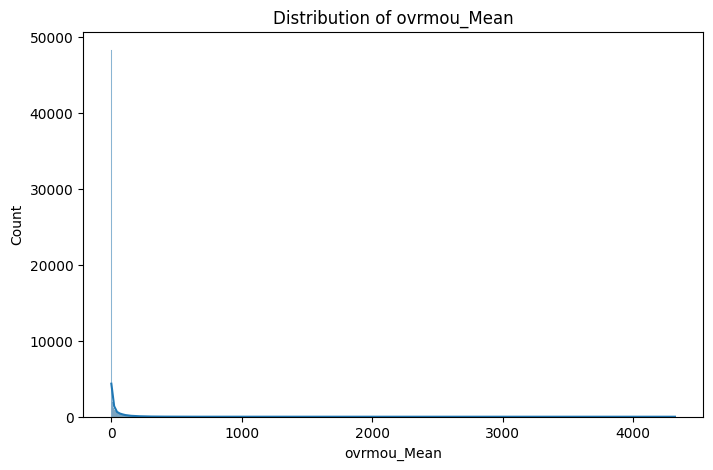

Skewness: 7.4180832865804645
**********


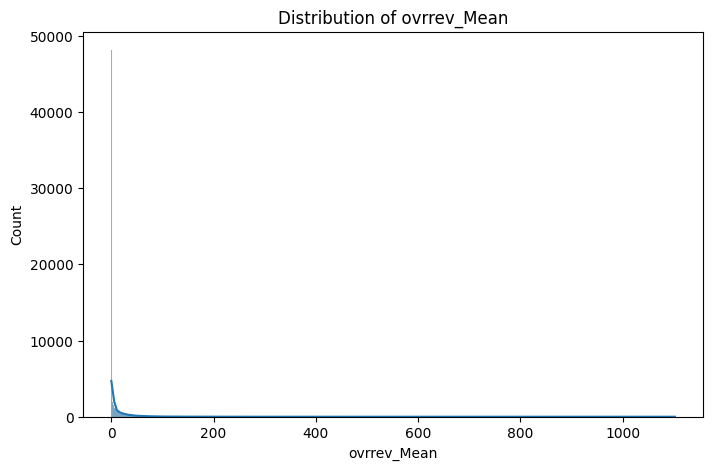

Skewness: 6.221423677789213
**********


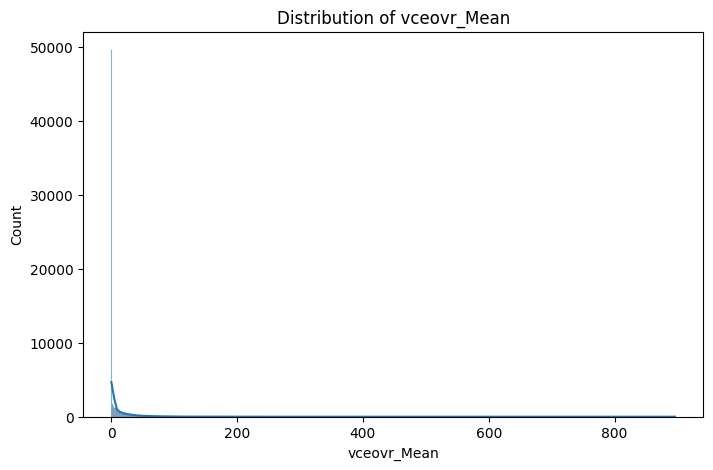

Skewness: 6.014158101007997
**********


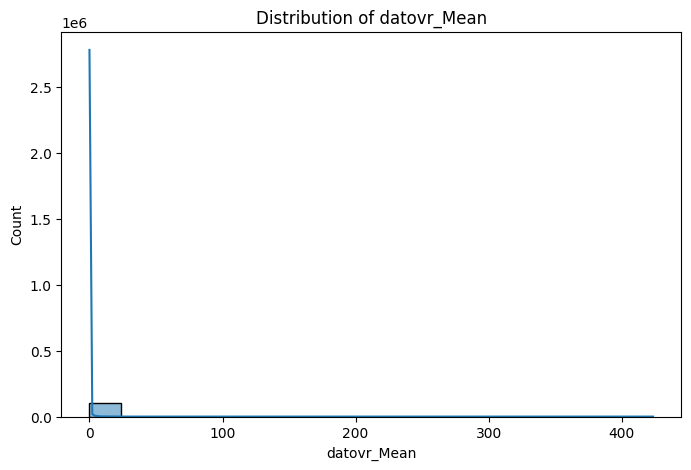

Skewness: 58.00787190361167
**********


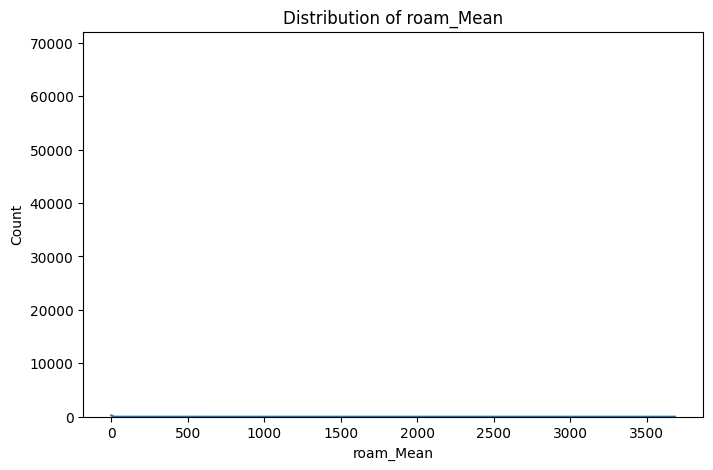

Skewness: 168.80778526689807
**********


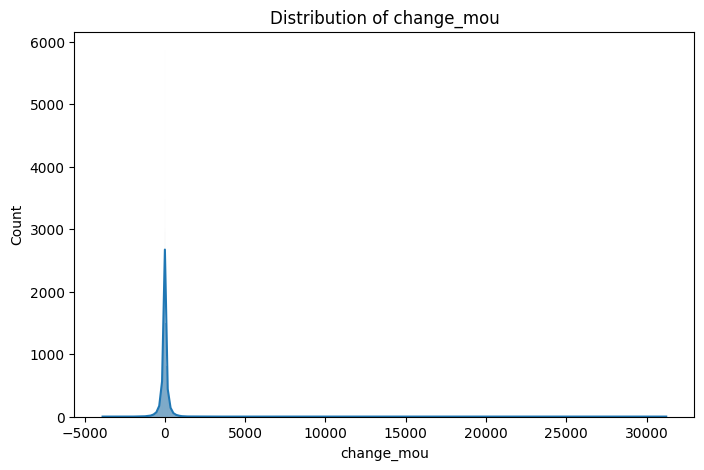

Skewness: 14.390948930657682
**********


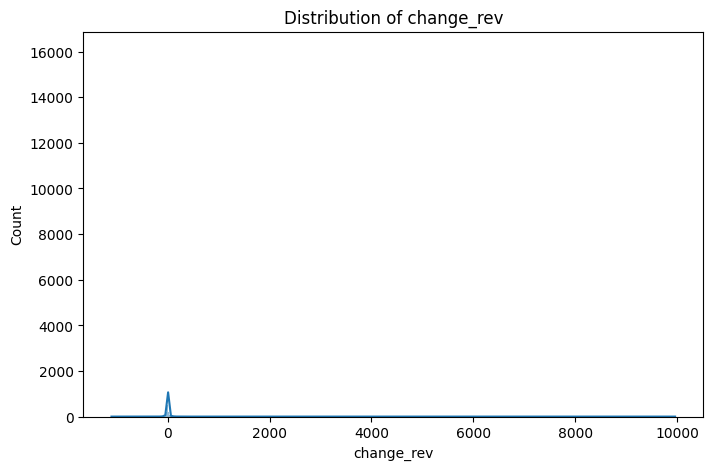

Skewness: 80.53542003400757
**********


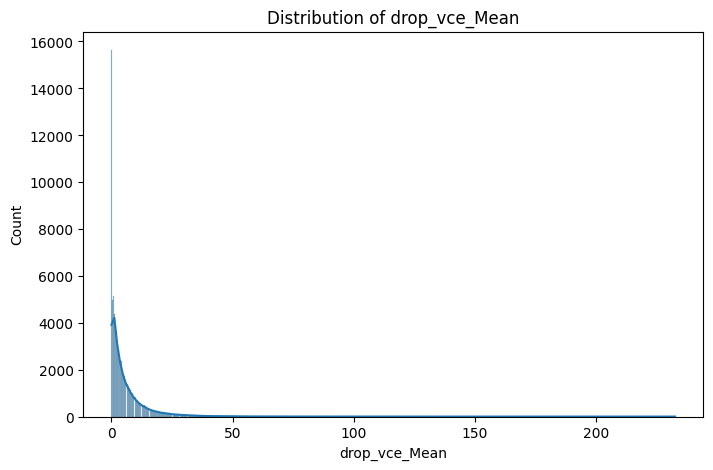

Skewness: 4.611948342788863
**********


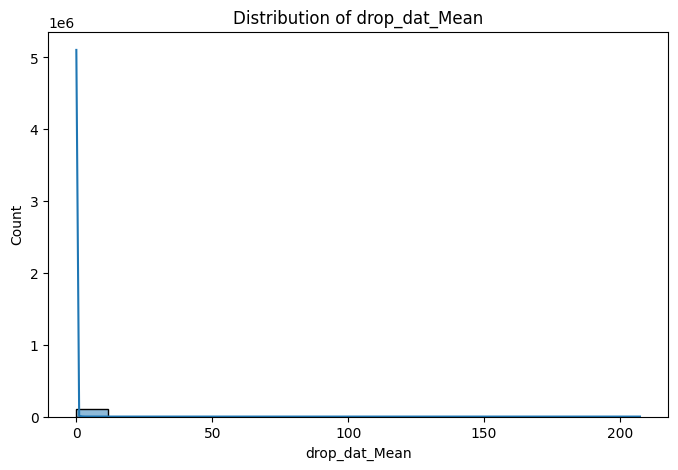

Skewness: 149.64042473425818
**********


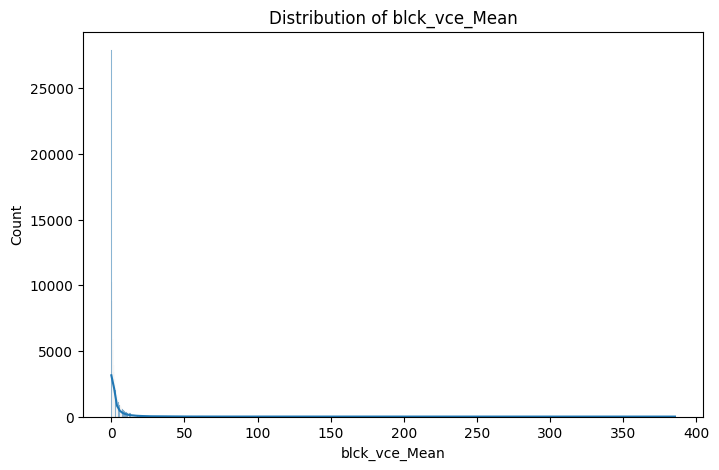

Skewness: 9.728314470015992
**********


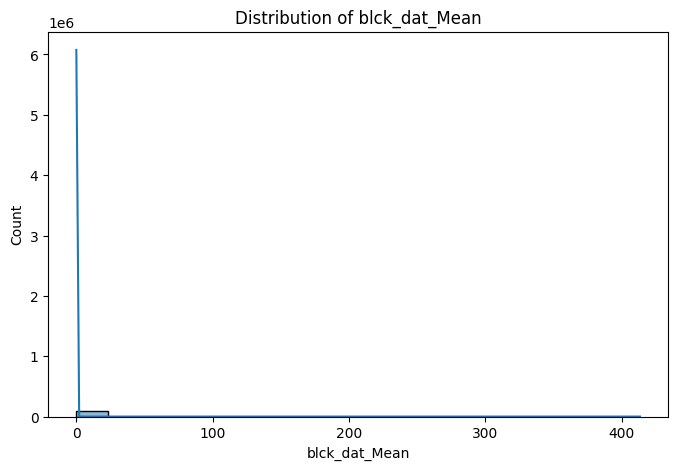

Skewness: 224.5998496966996
**********


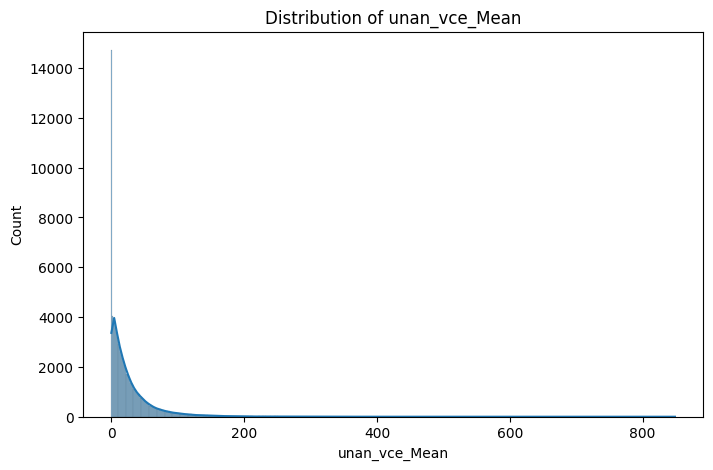

Skewness: 4.242731240026868
**********


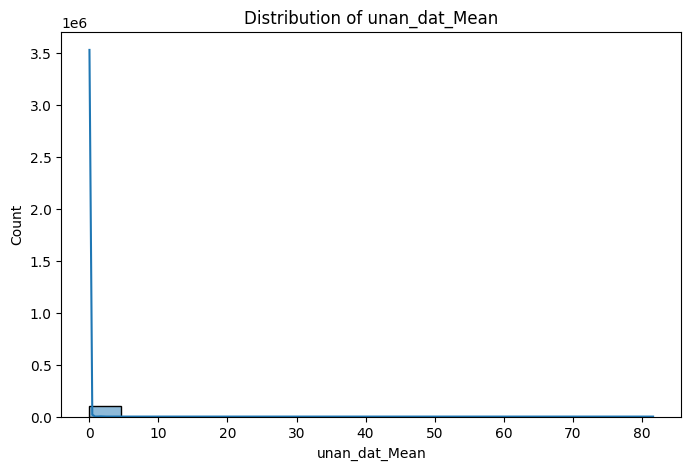

Skewness: 81.8135612551604
**********


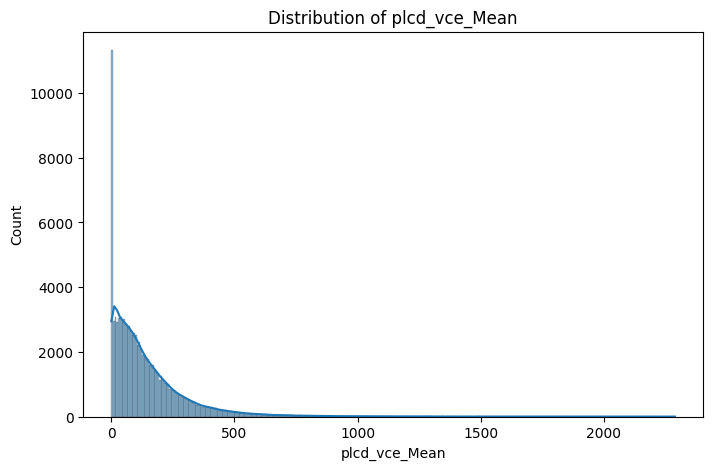

Skewness: 2.650357556583959
**********


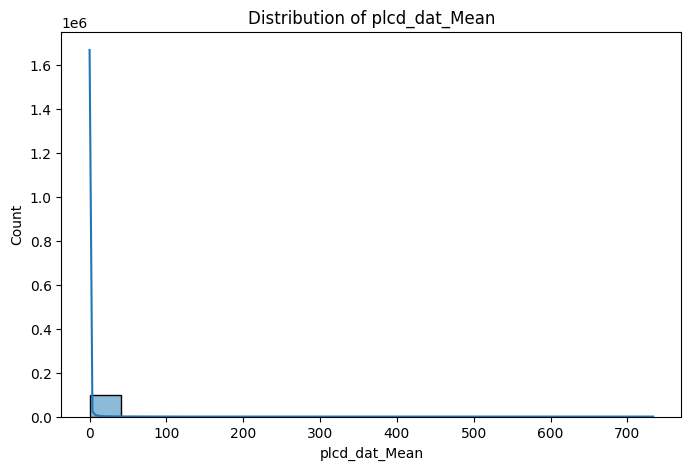

Skewness: 30.273576675835994
**********


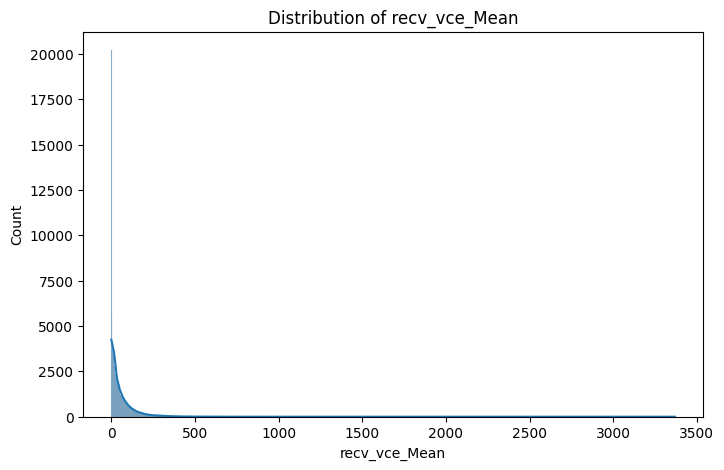

Skewness: 5.627871107666589
**********


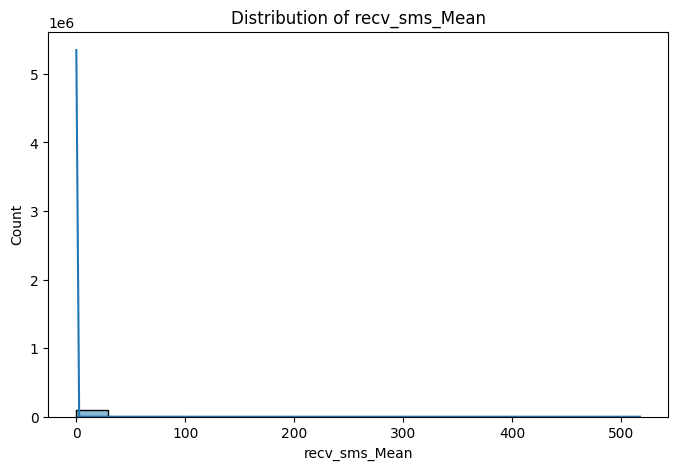

Skewness: 168.4392028055192
**********


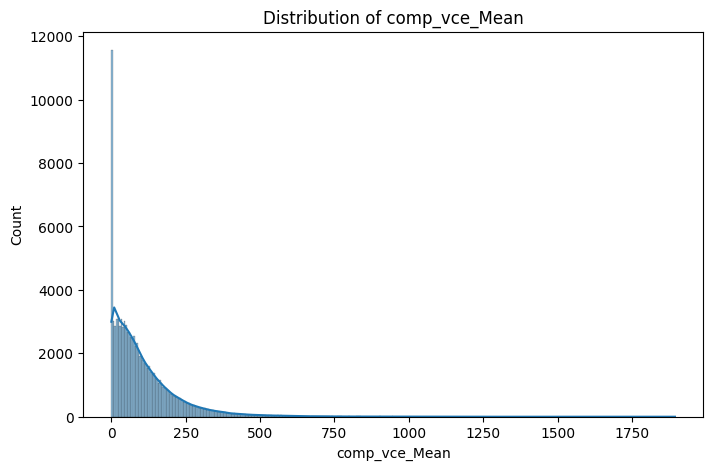

Skewness: 2.625488087458252
**********


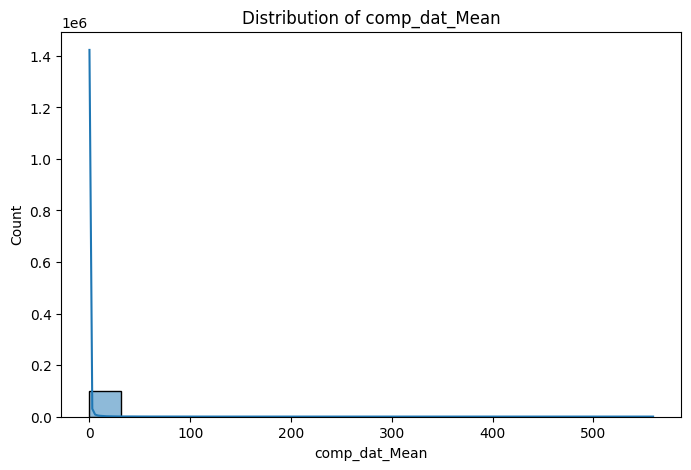

Skewness: 28.636399125899693
**********


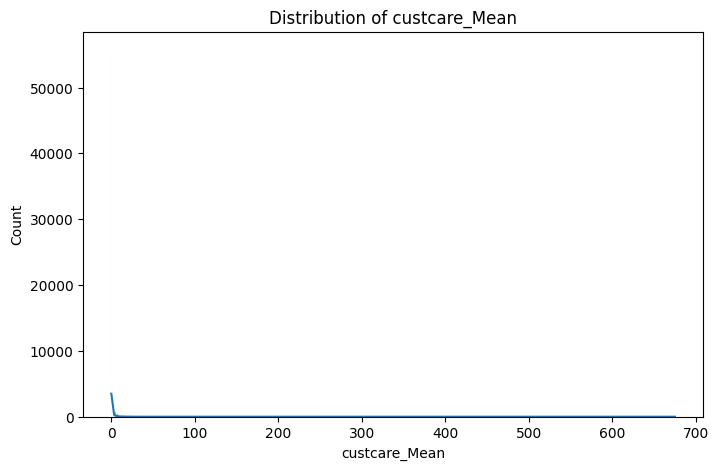

Skewness: 32.03250145545649
**********


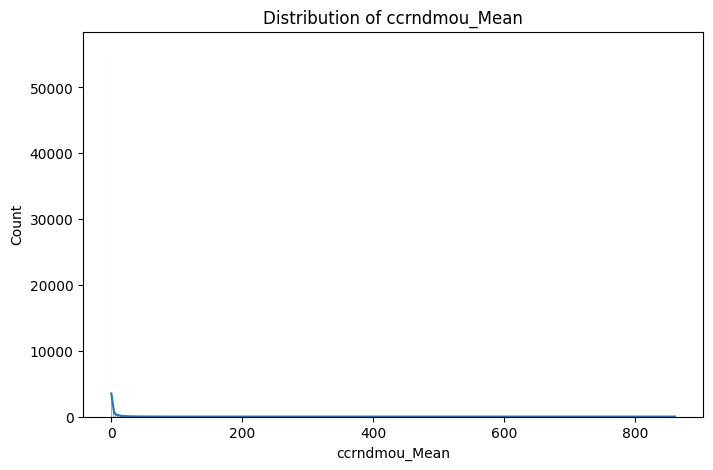

Skewness: 11.565861553838705
**********


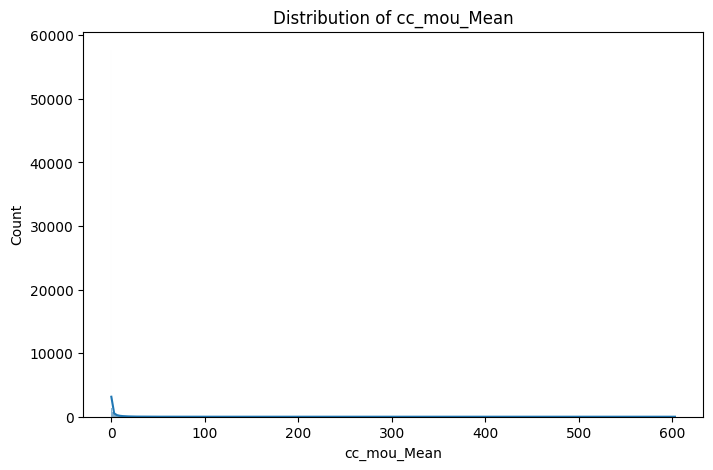

Skewness: 10.571779896143273
**********


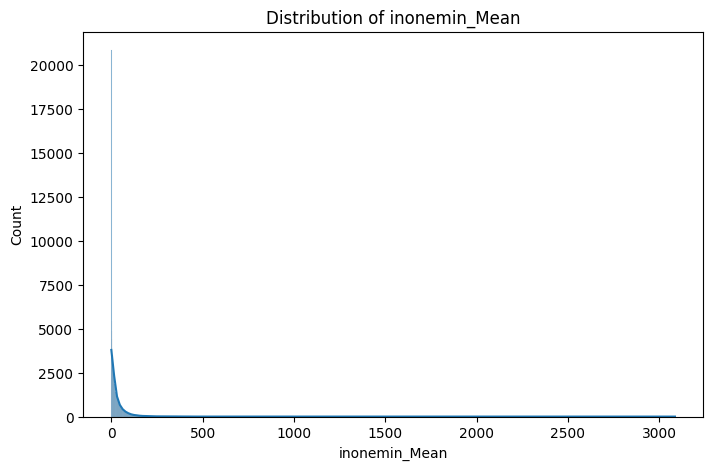

Skewness: 8.905458065263039
**********


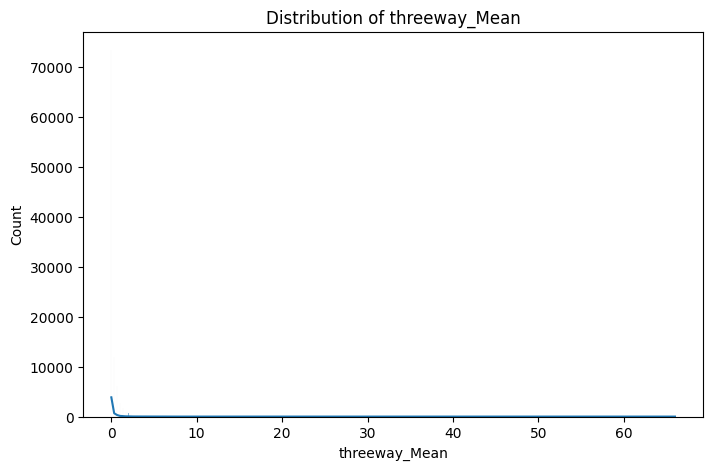

Skewness: 17.001073461994935
**********


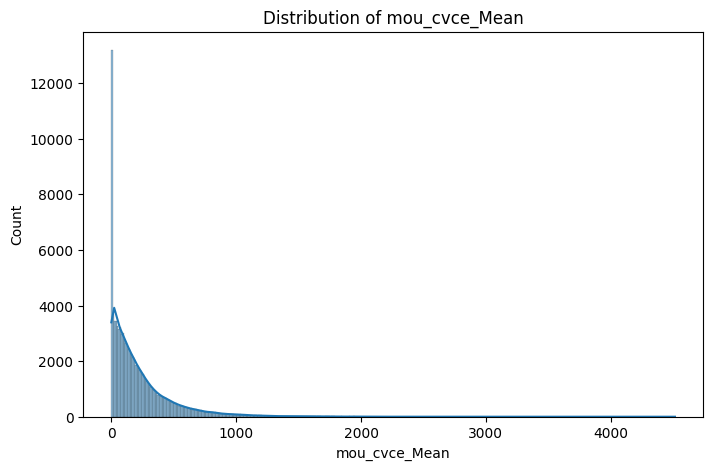

Skewness: 2.564346289603055
**********


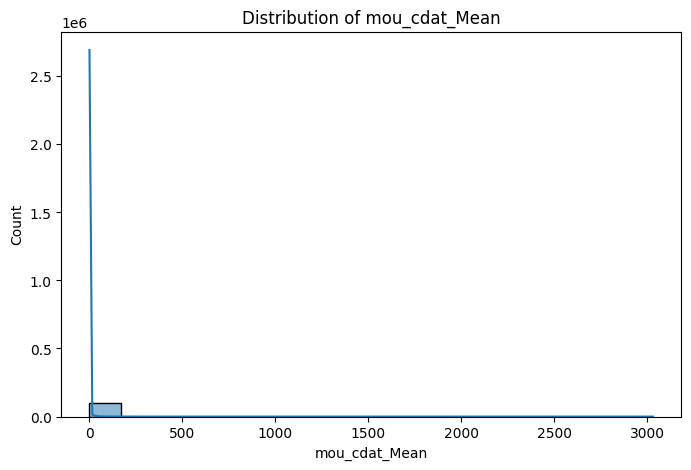

Skewness: 49.327626613602966
**********


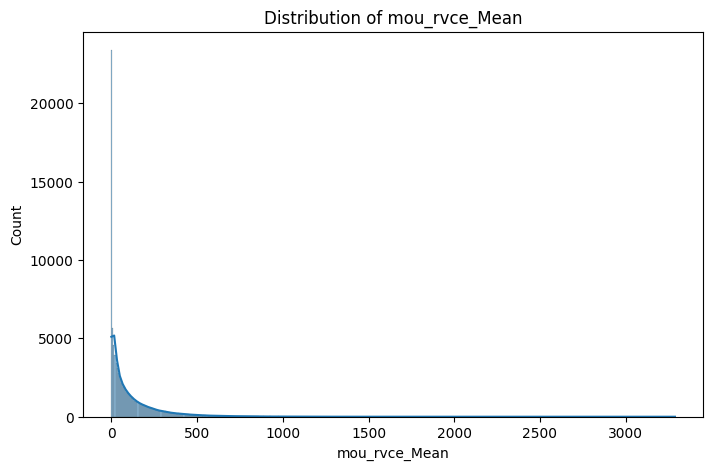

Skewness: 3.0855456368633387
**********


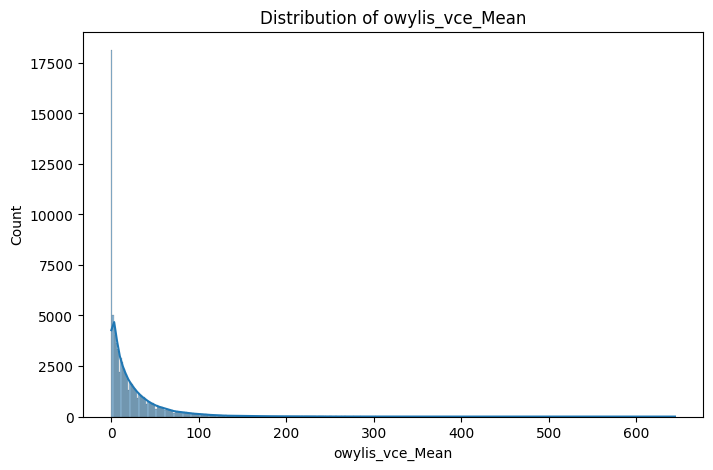

Skewness: 3.432737974721638
**********


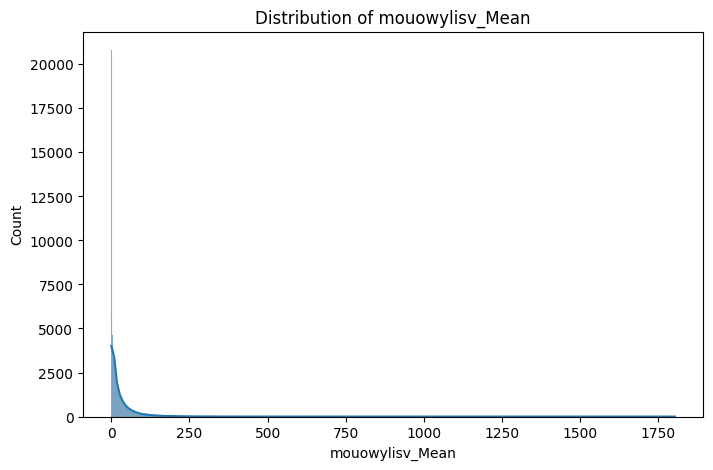

Skewness: 5.525898076767953
**********


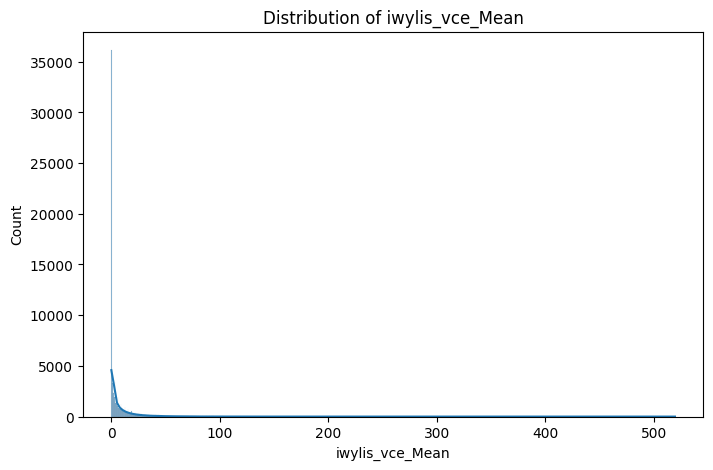

Skewness: 5.638543716473512
**********


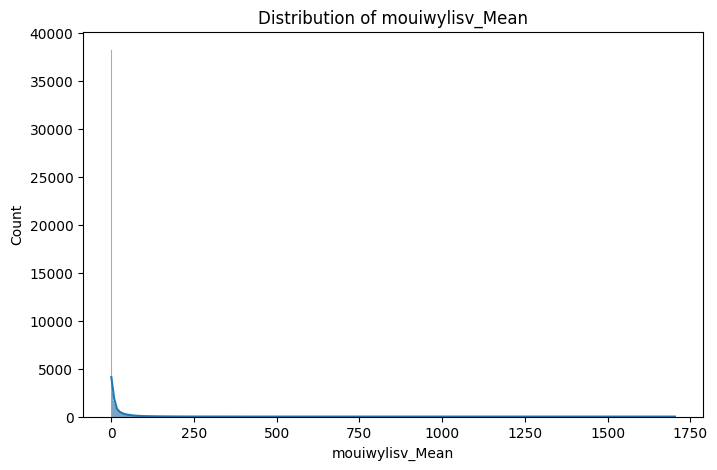

Skewness: 6.68108577379298
**********


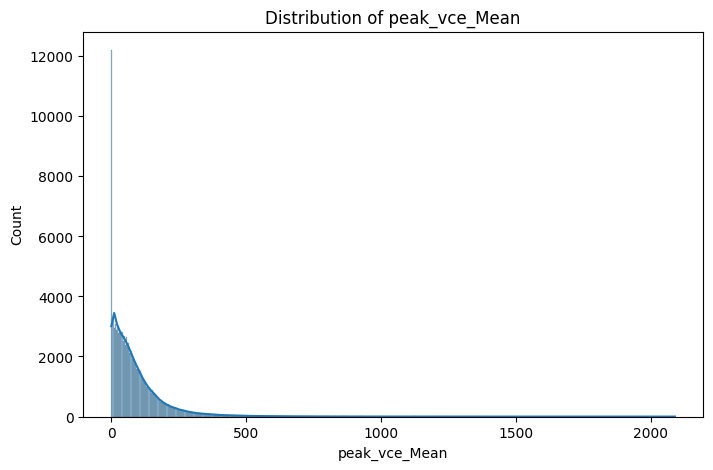

Skewness: 3.2239917666011837
**********


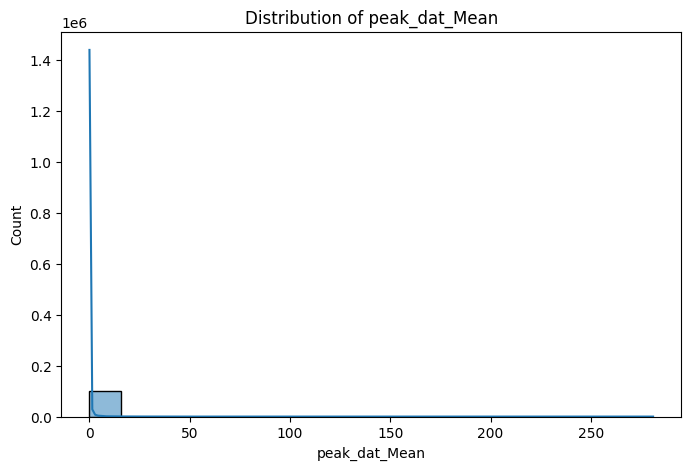

Skewness: 29.806483187225645
**********


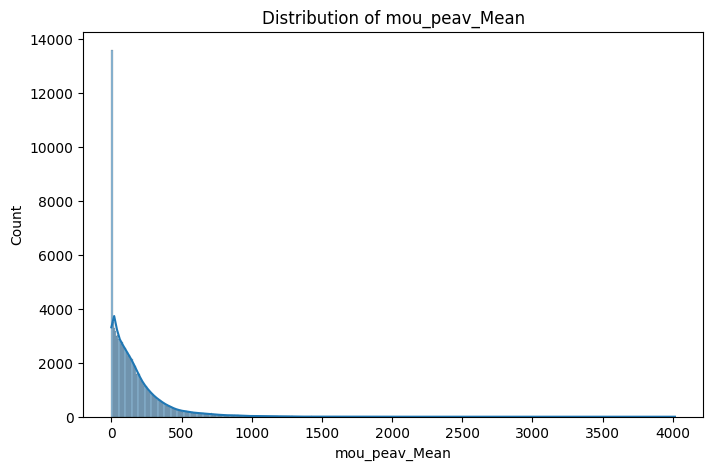

Skewness: 3.0587899035323627
**********


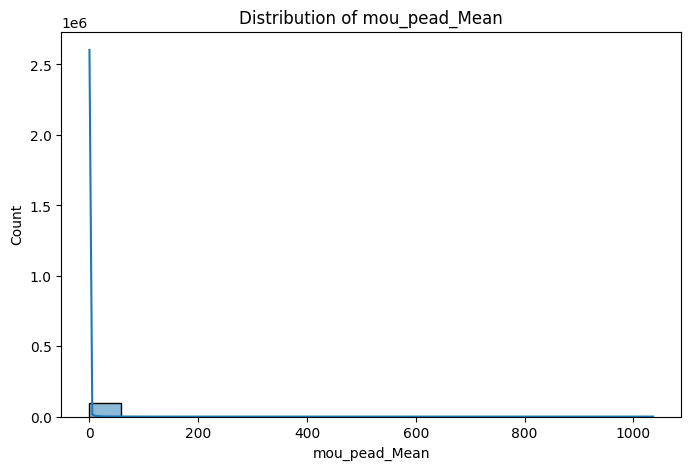

Skewness: 43.003811564791505
**********


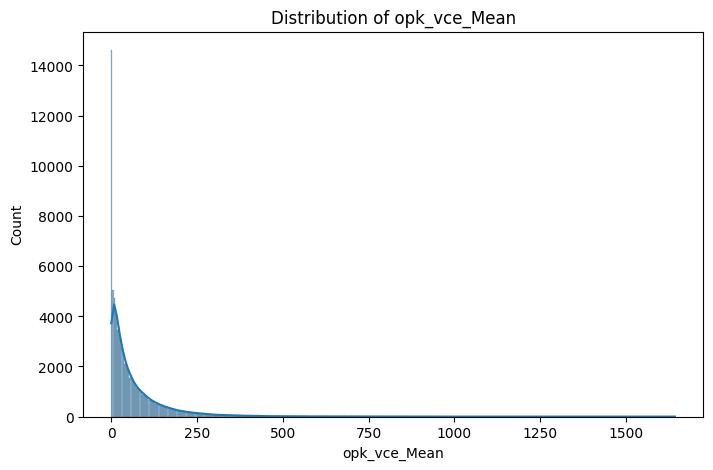

Skewness: 3.556608108892812
**********


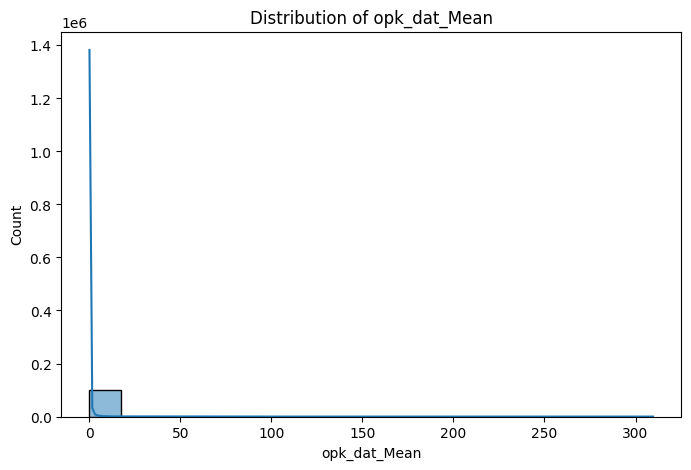

Skewness: 29.966403385837612
**********


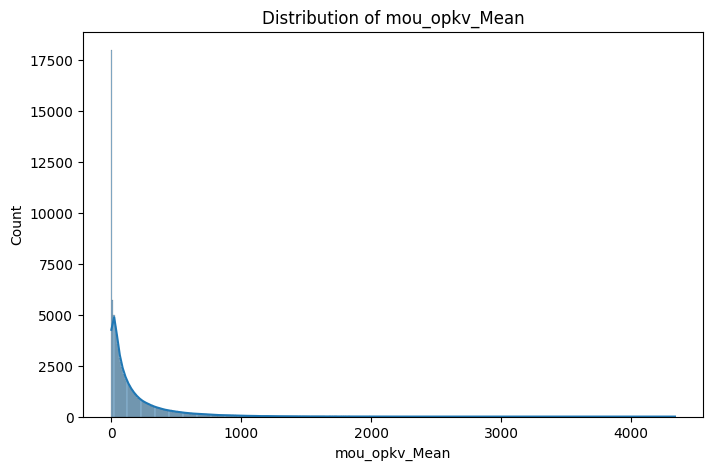

Skewness: 2.9000330066344855
**********


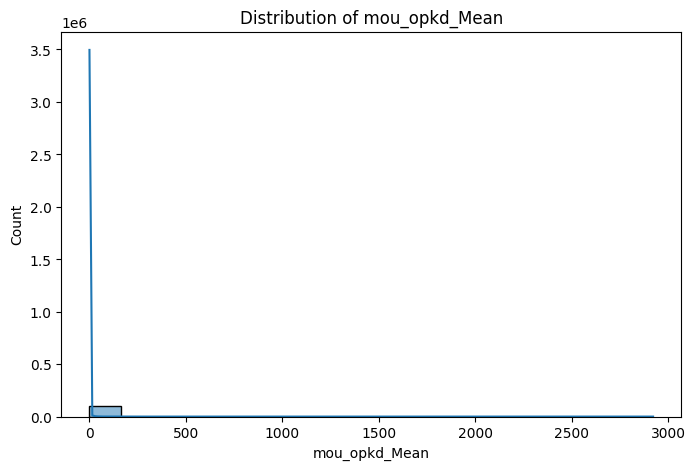

Skewness: 67.43540922711507
**********


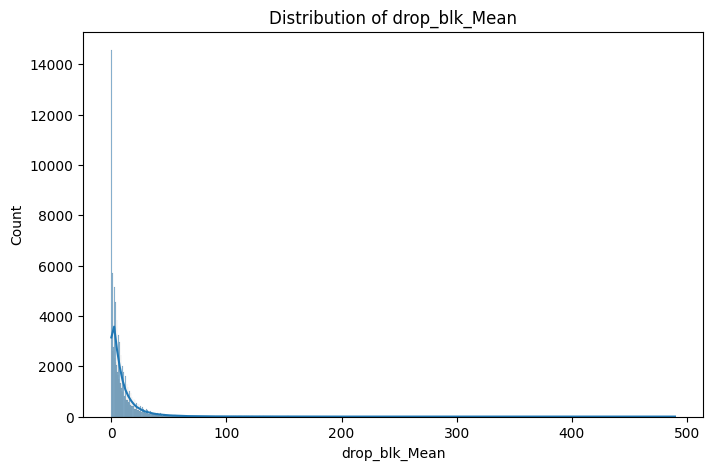

Skewness: 5.731060986021972
**********


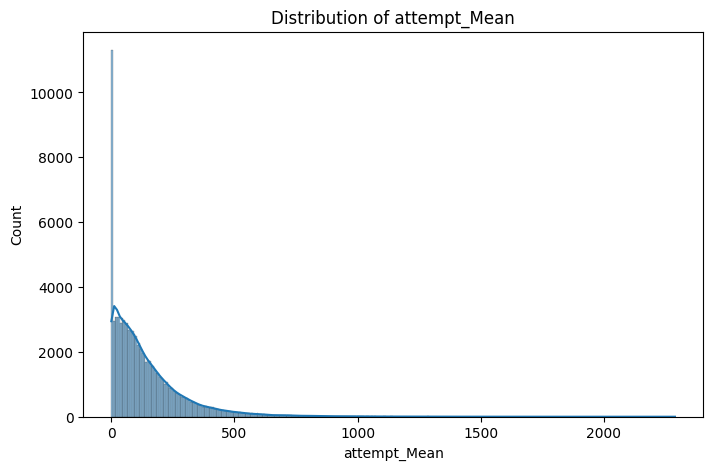

Skewness: 2.6415271734151085
**********


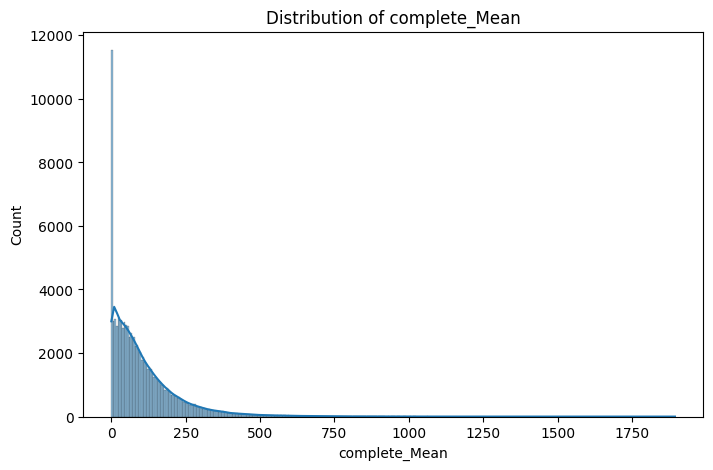

Skewness: 2.619507354714367
**********


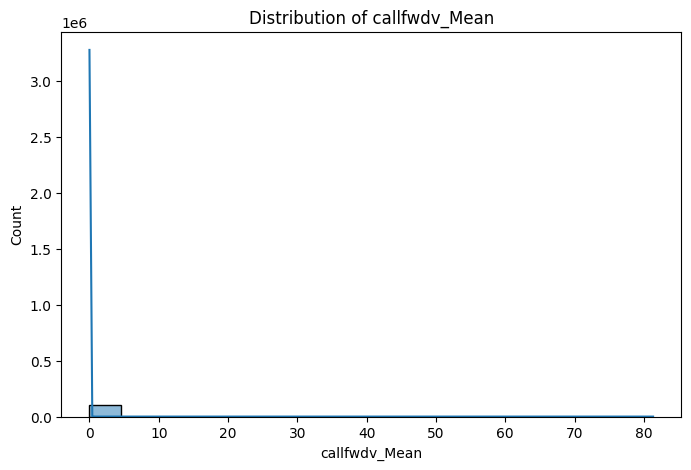

Skewness: 90.73779975727635
**********


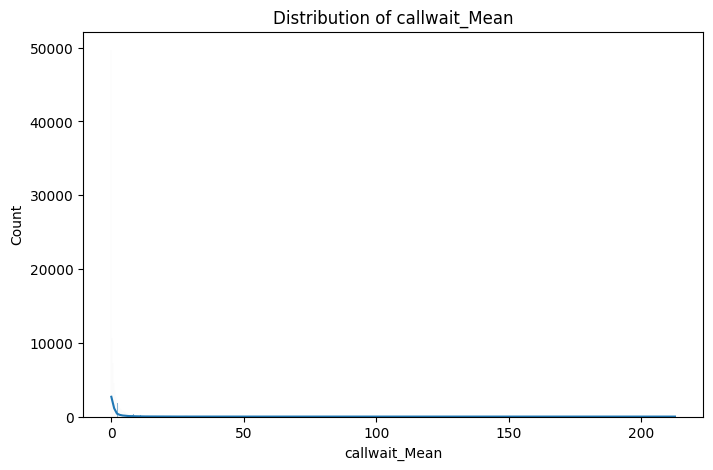

Skewness: 11.138120004786849
**********


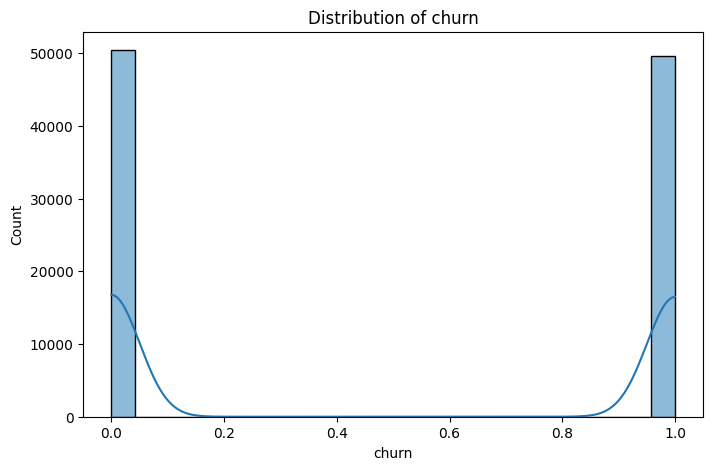

Skewness: 0.017520935075188288
**********


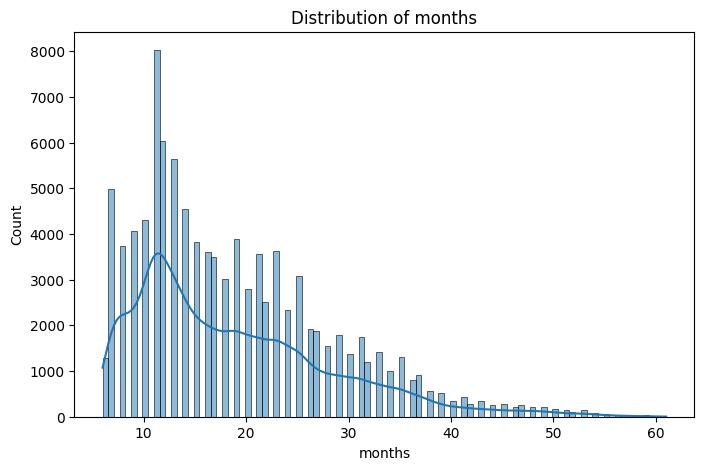

Skewness: 1.0602819076651748
**********


In [75]:
for col in numerical_col_:
  plt.figure(figsize=(8,5))
  sns.histplot(data[col], kde=True)
  plt.title(f'Distribution of {col}')
  plt.show()

  print("Skewness:", data[col].skew())
  print("*"*10)

# Several customer behavior patterns were identified during exploratory analysis:

* **Household Subscribers (uniqsubs):** Churn rate generally increased as the number of subscribers within the same household increased, suggesting that larger accounts may exhibit higher churn risk.

* **Revenue Distribution (rev_Mean):** Revenue showed a highly right-skewed distribution, with most customers concentrated in lower revenue ranges. Revenue patterns were relatively similar between churners and non-churners.

* **Usage Behavior (mou_Mean):** Non-churning customers tended to have higher average monthly usage, indicating that more engaged customers are less likely to leave the service.

* **Overage Revenue (ovrrev_Mean):** Customers who churned generated slightly higher overage charges on average, suggesting that unexpected or excessive usage costs may contribute to customer dissatisfaction.

* **Equipment Age (eqpdays):** Customers who churned had noticeably older devices than retained customers. This indicates that aging equipment may be associated with increased churn risk and represents a potential retention opportunity.

* **Customer Tenure (months / LOR):** An inverse relationship was observed between customer tenure and churn. Customers with shorter tenure exhibited higher churn rates, while long-term customers demonstrated stronger retention.




# **Data Preprocessing**

In [15]:
categorical_col=df.select_dtypes(include=['category','object']).columns.to_list()
for col in categorical_col:
  print(col)
  print("*"*10)
  print(data[col].unique())
  print("*"*10)

new_cell
**********
['U' 'N' 'Y']
**********
crclscod
**********
['A' 'EA' 'C' 'B' 'BA' 'D' 'G' 'CA' 'I' 'AA' 'J' 'U' 'Z' 'K' 'E' 'E4' 'W'
 'DA' 'Y' 'CC' 'GA' 'D4' 'D5' 'H' 'ZA' 'JF' 'B2' 'IF' 'Z1' 'O' 'M' 'L'
 'U1' 'Z4' 'A2' 'V' 'TP' 'EM' 'C2' 'C5' 'S' 'EC' 'Z5' 'D2' 'GY' 'ZY' 'E2'
 'A3' 'V1' 'EF' 'Z2' 'CY' 'P1' 'ZF']
**********
asl_flag
**********
['N' 'Y']
**********
prizm_social_one
**********
['S' 'U' 'T' 'C' nan 'R']
**********
area
**********
['NORTHWEST/ROCKY MOUNTAIN AREA' 'CHICAGO AREA' 'GREAT LAKES AREA'
 'NEW ENGLAND AREA' 'DALLAS AREA' 'CENTRAL/SOUTH TEXAS AREA'
 'TENNESSEE AREA' 'MIDWEST AREA' 'PHILADELPHIA AREA' 'OHIO AREA'
 'HOUSTON AREA' 'SOUTHWEST AREA' 'NEW YORK CITY AREA'
 'ATLANTIC SOUTH AREA' 'SOUTH FLORIDA AREA' 'CALIFORNIA NORTH AREA'
 'DC/MARYLAND/VIRGINIA AREA' 'NORTH FLORIDA AREA' nan 'LOS ANGELES AREA']
**********
dualband
**********
['Y' 'N' 'T' 'U' nan]
**********
refurb_new
**********
['N' 'R' nan]
**********
hnd_webcap
**********
['WCMB' 'WC' nan 'UNKW']

In [16]:
binary_cols = []
continuous_cols = []

for col in numerical_col_:
    unique_vals = data[col].dropna().unique()

    if len(unique_vals) == 2 and set(unique_vals).issubset({0, 1}):
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print("Binary Columns (0/1):")
print(binary_cols)

print("\nContinuous Columns:")
print(continuous_cols)

Binary Columns (0/1):
['truck', 'rv', 'forgntvl', 'churn']

Continuous Columns:
['uniqsubs', 'actvsubs', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'hnd_price', 'phones', 'models', 'lor', 'adults', 'income', 'numbcars', 'eqpdays', 'Customer_ID', 'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean', 'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean', 'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean', 'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'mou_peav_Mean', 'mou_pead_Mean', 'opk_v

In [17]:
data['income'].unique()

array([ 4.,  5.,  6.,  9.,  1.,  7.,  3., nan,  8.,  2.])

In [18]:
data['lor'].unique()

array([15.,  1.,  7.,  6.,  5.,  8.,  0.,  3.,  4., 11., 10., 13., nan,
        2., 14., 12.,  9.])

In [19]:
data['hnd_price'].unique()

array([149.9899902 ,          nan,  29.98999023, 129.9899902 ,
        79.98999023, 199.9899902 ,  59.98999023,  99.98999023,
         9.98999786, 299.9899902 , 399.9899902 ,  39.98999023,
       499.9899902 , 249.9899902 , 239.9899902 , 179.9899902 ,
       159.9899902 , 119.9899902 ])

In [20]:
dominant_value_ratio = data['datovr_Mean'].value_counts(normalize=True).iloc[0]
print(f"Frequent values represent {dominant_value_ratio * 100:.2f}% from data")

Frequent values represent 86.28% from data


In [21]:
dominant_value_ratio2 = data['roam_Mean'].value_counts(normalize=True).iloc[0]
print(f"Frequent values represent {dominant_value_ratio2 * 100:.2f}% from data")

Frequent values represent 68.90% from data


In [22]:
churn_by_subs = data.groupby('uniqsubs')['churn'].agg(['count', 'mean']).reset_index()

churn_by_subs['churn_rate_%'] = churn_by_subs['mean'] * 100

print(churn_by_subs.head(10))
print(churn_by_subs.tail(10))


   uniqsubs  count      mean  churn_rate_%
0         1  61966  0.476665     47.666462
1         2  27556  0.522246     52.224561
2         3   6579  0.528652     52.865177
3         4   2556  0.548905     54.890454
4         5    835  0.534132     53.413174
5         6    315  0.574603     57.460317
6         7    111  0.612613     61.261261
7         8     40  0.700000     70.000000
8         9     20  0.700000     70.000000
9        10      9  0.777778     77.777778
    uniqsubs  count      mean  churn_rate_%
5          6    315  0.574603     57.460317
6          7    111  0.612613     61.261261
7          8     40  0.700000     70.000000
8          9     20  0.700000     70.000000
9         10      9  0.777778     77.777778
10        11      5  0.800000     80.000000
11        12      4  0.250000     25.000000
12        13      2  1.000000    100.000000
13        18      1  1.000000    100.000000
14       196      1  1.000000    100.000000


In [23]:
dt=data.copy()
def verify_clipping(val):
    if val >= 7:
        return "7 or more (Clipped)"
    else:
        return str(val)

dt['check_group'] = dt['uniqsubs'].apply(verify_clipping)
clipping_summary = dt.groupby('check_group')['churn'].agg(['count', 'mean'])
clipping_summary['churn_rate_%'] = clipping_summary['mean'] * 100

print(clipping_summary)

                     count      mean  churn_rate_%
check_group                                       
1                    61966  0.476665     47.666462
2                    27556  0.522246     52.224561
3                     6579  0.528652     52.865177
4                     2556  0.548905     54.890454
5                      835  0.534132     53.413174
6                      315  0.574603     57.460317
7 or more (Clipped)    193  0.652850     65.284974


In [24]:

lower_bound = data['change_mou'].quantile(0.01)
upper_bound = data['change_mou'].quantile(0.99)

print(f"(1st percentile): {lower_bound}")
print(f"(99th percentile): {upper_bound}")

(1st percentile): -835.98
(99th percentile): 751.4599999999991


In [25]:
dt['change_mou_clipped'] = dt['change_mou'].clip(lower=-834.0, upper=747.0)

print(f"OLD Skewness: {dt['change_mou'].skew():.2f}")
print(f"NEW Skewness after clipping: {dt['change_mou_clipped'].skew():.2f}")

OLD Skewness: 14.39
NEW Skewness after clipping: -0.21


In [26]:
lower_bound_rev = data['change_rev'].quantile(0.01)
upper_bound_rev = data['change_rev'].quantile(0.99)

print(f"lower_bound_rev: {lower_bound_rev}")
print(f"upper_bound_rev: {upper_bound_rev}")

lower_bound_rev: -104.5743
upper_bound_rev: 121.8824999999999


In [27]:
dt['change_rev_clipped'] = dt['change_rev'].clip(lower=-104.1026, upper=121.2926)

print(f"OLD Skewness: {dt['change_rev'].skew():.2f}")
print(f"NEW Skewness after clipping: {dt['change_rev_clipped'].skew():.2f}")

OLD Skewness: 80.54
NEW Skewness after clipping: 0.57


In [28]:
dominant_callwait = data['callwait_Mean'].value_counts(normalize=True).iloc[0]
print(f"Frequent values represent {dominant_callwait * 100:.2f} % from data")

Frequent values represent 49.69 % from data


In [29]:
upper_bound_callwait = data['callwait_Mean'].quantile(0.99)
print(f"(99th percentile): {upper_bound_callwait}")

(99th percentile): 22.33333333


In [30]:
upper_bound_callwait = dt['callwait_Mean'].quantile(0.99)

dt['callwait_Mean_clipped'] = dt['callwait_Mean'].clip(upper=upper_bound_callwait)

dt = dt.drop(columns=['callwait_Mean'])

print(f"Original Skewness: 11.14")
print(f"New Skewness after Clipping: {dt['callwait_Mean_clipped'].skew():.2f}")

Original Skewness: 11.14
New Skewness after Clipping: 3.70


In [31]:
pd.crosstab(data['lor'],data['churn'],normalize='index')

churn,0,1
lor,,
0.0,0.468308,0.531692
1.0,0.482328,0.517672
2.0,0.485476,0.514524
3.0,0.502137,0.497863
4.0,0.508227,0.491773
5.0,0.519481,0.480519
6.0,0.518395,0.481605
7.0,0.533849,0.466151
8.0,0.520650,0.479350


In [32]:
def preprocessing(df_train, df_test):


  """
    Cleans, transforms, and prepares raw data for training and testing.

    Design Decisions & Data Science Logic:
    --------------------------------------
    1. Data Isolation: Training and testing sets are copied and treated separately
       to prevent any form of Data Leakage.
    2. High Cardinality Reduction: Truncates 'crclscod' (Credit Class Code) to its
       first character to group customers into broader risk categories and prevent overfitting.
    3. Missing Value Handling (Imputation):
       - Categorical missing values are filled with 'Unknown'.
       - Continuous missing values are imputed using the TRAINING set's median.
       - Binary missing values are imputed using the TRAINING set's mode.
       *Imputing test values with training statistics strictly prevents data leakage.
    4. Categorical Consolidation: Standardizes messy or shorthand values (e.g., mapping 'S' to 'Single family')
       to improve consistency across training and testing data.
    5. Outlier Mitigation (Clipping): Applies robust clipping based on training percentiles
       (1st and 99th) to cap extreme continuous features without losing data points.

    """
  df_train = df_train.copy()
  df_test = df_test.copy()


  categorical_cols = df_train.select_dtypes(include=['category', 'object']).columns.to_list()
  numerical_cols = df_train.select_dtypes(include='number').columns.to_list()

  binary_cols = []
  continuous_cols = []
  for col in numerical_cols:
        unique_vals = df_train[col].dropna().unique()
        if len(unique_vals) == 2 and set(unique_vals).issubset({0, 1}):
            binary_cols.append(col)
        else:
            continuous_cols.append(col)


  for df in [df_train, df_test]:
        df['crclscod'] = df['crclscod'].astype(str).str[0]

        for col in categorical_cols:
            df[col] = df[col].replace(['nan', 'NaN', None], np.nan)
            df[col] = df[col].fillna("Unknown")
            df[col] = df[col].replace({"U": "Unknown"})
            df[col] = df[col].astype('category')

        df['dwlltype'] = df['dwlltype'].replace({'S': 'Single family', 'M': 'Multi family'})
        df['ownrent'] = df['ownrent'].replace({"O": "Own", "R": "Rent"})
        df['prizm_social_one'] = df['prizm_social_one'].replace({"S": "Suburban", "T": "Town", "C": "City", "R": "Rural"})
        df['dualband'] = df['dualband'].replace({"T": "Y"})
        df['marital'] = df['marital'].replace({"M": "Married", "S": "Single", "A": "Separated", "B": "Married"})
        df['HHstatin'] = df['HHstatin'].replace({'A': 'High_value_household', 'B': 'Mid_high_value', 'C': 'Mid_value', 'G': 'Geographic_segment', 'H': 'Geographic_segment', 'I': 'Low_value'})
        df['ethnic'] = df['ethnic'].replace({'A': 'Group_1', 'B': 'Group_1', 'C': 'Group_1', 'D': 'Group_2', 'E': 'Group_2', 'F': 'Group_3', 'G': 'Group_3', 'H': 'Group_3', 'R': 'Special_category', 'P': 'Special_category', 'X': 'Special_category', 'Z': 'Unknown'})


  for col in continuous_cols:
        median_val = df_train[col].median()
        df_train[col] = df_train[col].fillna(median_val)
        df_test[col] = df_test[col].fillna(median_val)

  for col in binary_cols:
        mode_val = df_train[col].mode()[0] if not df_train[col].mode().empty else 0
        df_train[col] = df_train[col].fillna(mode_val).astype('object')
        df_test[col] = df_test[col].fillna(mode_val).astype('object')


  df_train['uniqsubs_clipped'] = df_train['uniqsubs'].clip(upper=7)
  df_test['uniqsubs_clipped'] = df_test['uniqsubs'].clip(upper=7)


  lower_mou, upper_mou = df_train['change_mou'].quantile(0.01), df_train['change_mou'].quantile(0.99)
  df_train['change_mou_clipped'] = df_train['change_mou'].clip(lower=lower_mou, upper=upper_mou)
  df_test['change_mou_clipped'] = df_test['change_mou'].clip(lower=lower_mou, upper=upper_mou)


  lower_rev, upper_rev = df_train['change_rev'].quantile(0.01), df_train['change_rev'].quantile(0.99)
  df_train['change_rev_clipped'] = df_train['change_rev'].clip(lower=lower_rev, upper=upper_rev)
  df_test['change_rev_clipped'] = df_test['change_rev'].clip(lower=lower_rev, upper=upper_rev)


  upper_wait = df_train['callwait_Mean'].quantile(0.99)
  df_train['callwait_Mean_clipped'] = df_train['callwait_Mean'].clip(upper=upper_wait)
  df_test['callwait_Mean_clipped'] = df_test['callwait_Mean'].clip(upper=upper_wait)


  drop_cols = ['uniqsubs', 'change_mou', 'change_rev', 'callwait_Mean', 'Customer_ID']
  df_train.drop(columns=drop_cols, inplace=True, errors='ignore')
  df_test.drop(columns=drop_cols, inplace=True, errors='ignore')

  return df_train, df_test, continuous_cols

# **Feature Engineering**

In [33]:
def feature_engineering(df_train, df_test):
    """
    Engineers new business-driven features and bins highly skewed numerical columns.

    Business Logic & Feature Engineering Rationales:
    ------------------------------------------------
    1. 'has_children': Consolidates multiple binary age-group columns into a single indicator.
       Simplifies the feature space and represents household demographic risk.
    2. 'mou_drop' & 'rev_drop': Captures usage and billing trends. A significant drop
       serves as a critical behavioral indicator that a customer is gradually disengaging.
    3. 'rev_per_min': Measures the cost efficiency of a customer's plan. High values indicate
       customers who pay a high price per minute, making them highly susceptible to competitor poaching.
    4. 'overage_ratio': Evaluates financial dissatisfaction. High overage revenue relative to total revenue
       means the customer frequently exceeds their plan boundaries, risking bill shock.
    5. 'tenure_years' & 'usage_intensity': Translates raw months into years for linear interpretability,
       and computes how heavily a customer consumes services relative to their overall tenure.
    6. 'network_issues_score': Aggregates dropped, blocked, and unanswered calls into a single distress metric.
       Directly measures technical network frustration, a primary driver of churn.
    7. 'has_data_overage' & 'is_roaming_user': Converts heavily skewed, zero-inflated continuous features
       into clean binary signals, isolating high-value specific behaviors.
    8. Quantile-Based Binning ('income_bin', 'lor_bin', 'hnd_price_bin'): Drops raw skewed distributions
       and maps values into structured intervals calculated strictly from training boundaries to avoid leakage.
    """

    df_train = df_train.copy()
    df_test = df_test.copy()

    kid_cols = ['kid0_2', 'kid11_15', 'kid16_17', 'kid3_5', 'kid6_10']
    issue_cols = ['drop_vce_Mean', 'blck_vce_Mean', 'unan_vce_Mean']

    for df in [df_train, df_test]:

        df['has_children'] = df[kid_cols].eq('Y').any(axis=1).astype(int)
        df.drop(columns=kid_cols, inplace=True, errors='ignore')


        df['mou_drop'] = df['avg3mou'] - df['mou_Mean']
        df['rev_drop'] = df['avg3rev'] - df['rev_Mean']


        df['rev_per_min'] = df['rev_Mean'] / (df['mou_Mean'] + 1)
        df['overage_ratio'] = df['ovrrev_Mean'] / (df['rev_Mean'] + 1)
        df['tenure_years'] = df['months'] / 12
        df['usage_intensity'] = df['mou_Mean'] / (df['months'] + 1)


        df['network_issues_score'] = df[issue_cols].sum(axis=1)


        df['has_data_overage'] = (df['datovr_Mean'] > 0).astype(int)
        df['is_roaming_user'] = (df['roam_Mean'] > 0).astype(int)
        df.drop(columns=['datovr_Mean', 'roam_Mean'], inplace=True, errors='ignore')


    income_bins = [df_train['income'].min()-1, 2, 4, 6, 8, max(10, df_train['income'].max())]
    lor_bins = [df_train['lor'].min()-1, 2, 5, 10, max(15, df_train['lor'].max())]
    hnd_bins = [df_train['hnd_price'].min()-1, 50, 150, 300, max(1000, df_train['hnd_price'].max())]

    for df in [df_train, df_test]:
        df['income_bin'] = pd.cut(df['income'], bins=income_bins, labels=False).fillna(-1)
        df['lor_bin'] = pd.cut(df['lor'], bins=lor_bins, labels=False).fillna(-1)
        df['hnd_price_bin'] = pd.cut(df['hnd_price'], bins=hnd_bins, labels=False).fillna(-1)

        df.drop(columns=['income', 'lor', 'hnd_price'], inplace=True, errors='ignore')

    return df_train, df_test

In [34]:
X = data.drop(columns=['churn','Customer_ID'])
y = data['churn']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

x_train_pre, x_test_pre, continuous_cols_cleaned = preprocessing(x_train, x_test)

x_train_final, x_test_final = feature_engineering(x_train_pre, x_test_pre)

exclude_from_pt = ['income_bin', 'lor_bin', 'hnd_price_bin', 'has_children', 'has_data_overage', 'is_roaming_user']
cont_col = [col for col in x_train_final.select_dtypes(include='number').columns if col not in exclude_from_pt]

/tmp/ipykernel_13049/337758854.py:29: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['dwlltype'] = df['dwlltype'].replace({'S': 'Single family', 'M': 'Multi family'})
/tmp/ipykernel_13049/337758854.py:30: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['ownrent'] = df['ownrent'].replace({"O": "Own", "R": "Rent"})
/tmp/ipykernel_13049/337758854.py:31: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the catego

In [35]:
x_train_final = x_train_final.copy()
x_test_final = x_test_final.copy()

pt = PowerTransformer(method='yeo-johnson')

x_train_final[cont_col] = pt.fit_transform(
    x_train_final[cont_col]
)

x_test_final[cont_col] = pt.transform(
    x_test_final[cont_col]
)

In [36]:
binary_cols = ['truck', 'rv', 'forgntvl']

for col in binary_cols:
    x_train_final[col] = x_train_final[col].astype('int8')
    x_test_final[col] = x_test_final[col].astype('int8')

In [37]:
cat_cols = x_train_final.select_dtypes(include=['category']).columns.tolist()
print(cat_cols)

['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'creditcd']


# **MODELS**

# **`XGBoost`**

In [38]:
def objective(trial):
    params = {
        "booster": "gbtree",
        "n_jobs": -1,
        "random_state": 42,
        "eval_metric": "auc",
        "enable_categorical": True,
        "scale_pos_weight": 1,
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-8, 10, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True)
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_aucs = []

    for train_idx, test_idx in skf.split(x_train_final, y_train):

        X_train_fold = x_train_final.iloc[train_idx].copy().astype({col: 'float64' for col in cont_col})
        X_test_fold = x_train_final.iloc[test_idx].copy().astype({col: 'float64' for col in cont_col})

        y_train_fold = y_train.iloc[train_idx]
        y_test_fold = y_train.iloc[test_idx]

        model_xg = XGBClassifier(**params)

        model_xg.fit(X_train_fold, y_train_fold)
        preds = model_xg.predict_proba(X_test_fold)[:, 1]

        auc = roc_auc_score(y_test_fold, preds)
        fold_aucs.append(auc)

    return np.mean(fold_aucs)


In [39]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

In [40]:
print("Best AUC:", study.best_value)
print("Best Params:", study.best_params)

Best AUC: 0.6957752562305553
Best Params: {'n_estimators': 534, 'max_depth': 7, 'learning_rate': 0.030225401374025962, 'subsample': 0.958266530935138, 'colsample_bytree': 0.7100379497147261, 'gamma': 2.7801970619315726e-05, 'min_child_weight': 7, 'reg_alpha': 0.003938042924734064, 'reg_lambda': 0.011320298774457557}


In [41]:
xg=study.best_params

In [42]:
def objective(trial):


    n_estimators = trial.suggest_int("n_estimators", 300, 600)
    num_leaves = trial.suggest_int("num_leaves",5,40)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    learning_rate=trial.suggest_float("learning_rate",0.01,0.3,log=True)
    subsample=trial.suggest_float("subsample",0.5,1)
    colsample_bytree=trial.suggest_float("colsample_bytree",0.5,1)
    min_child_samples=trial.suggest_int("min_child_samples",10,60)

    reg_alpha = trial.suggest_float("reg_alpha", 1e-3, 10, log=True)
    reg_lambda = trial.suggest_float("reg_lambda", 1e-3, 10, log=True)

    min_split_gain = trial.suggest_float("min_split_gain", 0.0, 1.0)

    subsample_freq = trial.suggest_int("subsample_freq", 1, 10)

    min_child_weight = trial.suggest_float("min_child_weight", 1e-3, 10, log=True)

    max_bin = trial.suggest_int("max_bin", 100, 500)

    path_smooth = trial.suggest_float("path_smooth", 0.0, 10.0)

    feature_fraction_bynode = trial.suggest_float(
        "feature_fraction_bynode", 0.5, 1.0
    )

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []

    for train_idx, test_idx in skf.split(x_train_final, y_train):

        X_train_fold = x_train_final.iloc[train_idx].copy().astype({col: 'float64' for col in cont_col})
        X_test_fold = x_train_final.iloc[test_idx].copy().astype({col: 'float64' for col in cont_col})

        y_train_fold = y_train.iloc[train_idx]
        y_test_fold = y_train.iloc[test_idx]



        model_lg=LGBMClassifier(boosting_type="gbdt",n_jobs=-1,random_state=42,n_estimators=n_estimators,num_leaves=num_leaves,
                             max_depth=max_depth,learning_rate=learning_rate,subsample=subsample,colsample_bytree=colsample_bytree,
                             min_child_samples=min_child_samples,min_split_gain=min_split_gain,reg_alpha=reg_alpha,reg_lambda=reg_lambda,
                             subsample_freq=subsample_freq,min_child_weight=min_child_weight,max_bin=max_bin,path_smooth=path_smooth,
                             feature_fraction_bynode=feature_fraction_bynode)


        model_lg.fit(X_train_fold, y_train_fold,categorical_feature=True)

        preds = model_lg.predict_proba(X_test_fold)[:, 1]
        aucs.append(roc_auc_score(y_test_fold, preds))

    return np.mean(aucs)
study_lg = optuna.create_study(direction="maximize")
study_lg.optimize(objective, n_trials=30)

In [43]:
print("Best AUC:", study_lg.best_value)
print("Best Params:", study_lg.best_params)

Best AUC: 0.6965943267531419
Best Params: {'n_estimators': 600, 'num_leaves': 34, 'max_depth': 10, 'learning_rate': 0.03403441314343418, 'subsample': 0.8716349101235341, 'colsample_bytree': 0.5533436330246726, 'min_child_samples': 30, 'reg_alpha': 1.8216459477290294, 'reg_lambda': 0.0011437357998707823, 'min_split_gain': 0.31786442203226173, 'subsample_freq': 5, 'min_child_weight': 0.003452961330893891, 'max_bin': 205, 'path_smooth': 4.746380073078131, 'feature_fraction_bynode': 0.996533022724072}


In [44]:
lg= study_lg.best_params

# **`CatBoost`**

In [45]:
cat_col=x_train_final.select_dtypes(['category','object']).columns.to_list()

In [46]:
def objective(trial):


    params = {
        "iterations": trial.suggest_int("iterations", 300, 1200),
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 10, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 5, log=True),
        "border_count": trial.suggest_int("border_count", 32, 128),
        "rsm": trial.suggest_float("rsm", 0.6, 1.0),

        "bootstrap_type": "Bernoulli",
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),

        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 60),
        "allow_writing_files": False,
        "train_dir": "catboost_info",
        "random_seed": 42,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "verbose": 0
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_aucs = []

    for train_idx, test_idx in skf.split(x_train_final, y_train):

        X_train_fold = x_train_final.iloc[train_idx].copy().astype({col: 'float64' for col in cont_col})
        X_test_fold = x_train_final.iloc[test_idx].copy().astype({col: 'float64' for col in cont_col})

        y_train_fold = y_train.iloc[train_idx]
        y_test_fold = y_train.iloc[test_idx]



        model = CatBoostClassifier(**params)

        model.fit(
            X_train_fold, y_train_fold,
            cat_features=cat_col,
            eval_set=(X_test_fold, y_test_fold),
            use_best_model=True,
            early_stopping_rounds=50
        )

        preds = model.predict_proba(X_test_fold)[:, 1]
        auc = roc_auc_score(y_test_fold, preds)
        fold_aucs.append(auc)

    return np.mean(fold_aucs)
study2 = optuna.create_study(direction="maximize", study_name='catboost')
study2.optimize(objective, n_trials=30)

{'iterations': 961, 'depth': 7, 'learning_rate': 0.04296056846417805, 'l2_leaf_reg': 8.58334783077414, 'random_strength': 0.03982406275528633, 'border_count': 33, 'rsm': 0.7981194211421296, 'subsample': 0.8545743492260583, 'min_data_in_leaf': 21}

In [47]:
print("Best AUC:", study2.best_value)
print("Best Params:", study2.best_params)

In [48]:
cat=study2.best_param

# **Training Models**

# **Model Evaluation**

In [49]:
cat_cols_final = x_train_final.select_dtypes(include=['category', 'object']).columns.to_list()

print("Training XGBoost...")
xgb_model = XGBClassifier(
    booster="gbtree",
    random_state=SEED,
    n_jobs=-1,

    n_estimators=534,
    max_depth=7,
    learning_rate=0.030225401374025962,

    subsample=0.958266530935138,
    colsample_bytree=0.7100379497147261,

    gamma=2.7801970619315726e-05,
    min_child_weight=7,

    reg_alpha=0.003938042924734064,
    reg_lambda=0.011320298774457557,

    enable_categorical=True,
    eval_metric="auc")

xgb_model.fit(x_train_final, y_train_split := y_train)

print("Training LightGBM...")
lgb_model = LGBMClassifier(boosting_type="gbdt",
    n_jobs=-1,
    random_state=42,

    n_estimators=600,
    num_leaves=34,
    max_depth=10,
    learning_rate=0.03403441314343418,

    subsample=0.8716349101235341,
    colsample_bytree=0.5533436330246726,

    min_child_samples=30,
    min_split_gain=0.31786442203226173,
    min_child_weight=0.003452961330893891,

    reg_alpha=1.8216459477290294,
    reg_lambda=0.0011437357998707823,

    subsample_freq=5,
    max_bin=205,
    path_smooth=4.746380073078131,
    feature_fraction_bynode=0.996533022724072
)

for c in cat_cols_final:
    x_train_final[c] = x_train_final[c].astype('category')
    x_test_final[c] = x_test_final[c].astype('category')
lgb_model.fit(x_train_final, y_train, categorical_feature=cat_cols_final)

print("Training CatBoost...")

x_train_cb = x_train_final.copy()
x_test_cb = x_test_final.copy()
for c in cat_cols_final:
    x_train_cb[c] = x_train_cb[c].astype(str)
    x_test_cb[c] = x_test_cb[c].astype(str)

cat={'iterations': 961, 'depth': 7, 'learning_rate': 0.04296056846417805, 'l2_leaf_reg': 8.58334783077414,
     'random_strength': 0.03982406275528633, 'border_count': 33, 'rsm': 0.7981194211421296, 'subsample': 0.8545743492260583, 'min_data_in_leaf': 21}


cat.update({"allow_writing_files": False, "random_seed": SEED, "verbose": 0})

cb_model = CatBoostClassifier(**cat)
cb_model.fit(x_train_cb, y_train, cat_features=cat_cols_final)

Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 39650, number of negative: 40350
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.127933 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12566
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 101
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495625 -> initscore=-0.017500
[LightGBM] [Info] Start training from score -0.017500
Training CatBoost...


CatBoostClassifier(allow_writing_files=False, border_count=33, depth=7, iterations=961, l2_leaf_reg=8.58334783077414, learning_rate=0.04296056846417805, min_data_in_leaf=21, random_seed=42, random_strength=0.03982406275528633, rsm=0.7981194211421296, subsample=0.8545743492260583, verbose=0)


Classification Report

XGBoost
              precision    recall  f1-score   support

           0       0.64      0.63      0.64     10088
           1       0.63      0.65      0.64      9912

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000


Classification Report

LightGBM
              precision    recall  f1-score   support

           0       0.65      0.63      0.64     10088
           1       0.63      0.65      0.64      9912

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000


Classification Report

CatBoost
              precision    recall  f1-score   support

           0       0.65      0.62      0.64     10088
           1       0.63      0.65      0.64      9912

    accuracy                           0.64     20000
   macro avg       0.64      0

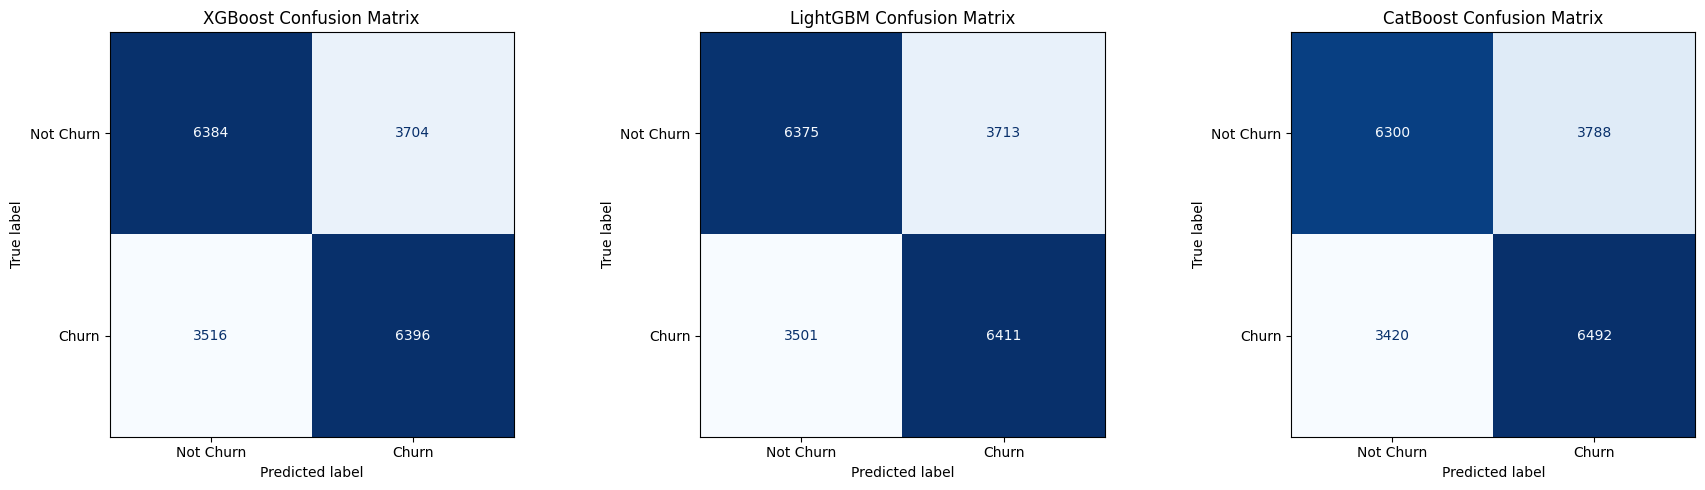


====== Comparison Table ======
             AUC  Accuracy  F1-Score
XGBoost   0.6955    0.6390    0.6392
LightGBM  0.6958    0.6393    0.6399
CatBoost  0.6962    0.6396    0.6430



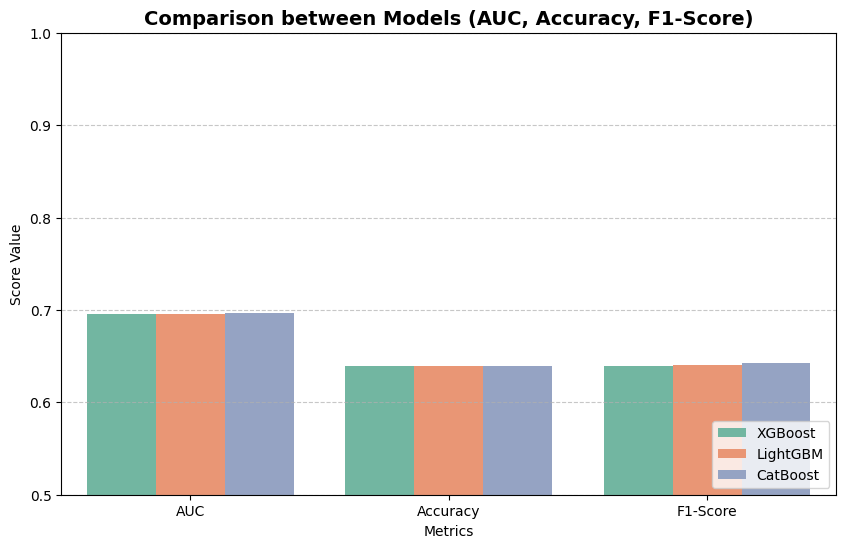

In [50]:
results = {}

models_dict = {
    'XGBoost': (xgb_model, x_test_final),
    'LightGBM': (lgb_model, x_test_final),
    'CatBoost': (cb_model, x_test_cb)
}


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (model_name, (model, X_test_data)) in enumerate(models_dict.items()):


    pred_proba2 = model.predict_proba(X_test_data)[:, 1]
    pred_labels2 = model.predict(X_test_data)
    pred_labels2 = np.array(pred_labels2).astype(int).flatten()


    auc = roc_auc_score(y_test, pred_proba2)
    acc = accuracy_score(y_test, pred_labels2)
    f1 = f1_score(y_test, pred_labels2)

    results[model_name] = {
        'AUC': auc,
        'Accuracy': acc,
        'F1-Score': f1
    }
    print("\nClassification Report")
    print("\n" + "=" * 50)
    print(model_name)
    print(classification_report(y_test, pred_labels2))


    cm = confusion_matrix(y_test, pred_labels2)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churn', 'Churn'])


    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{model_name} Confusion Matrix')

plt.tight_layout()
plt.show()


df_compare = pd.DataFrame(results).T
print("\n====== Comparison Table ======")
print(df_compare.round(4))
print("==============================\n")


df_compare_melted = df_compare.reset_index().melt(id_vars='index', var_name='Metric', value_name='Value')
df_compare_melted.rename(columns={'index': 'Model'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_compare_melted, x='Metric', y='Value', hue='Model', palette='Set2')
plt.ylim(0.5, 1.0)
plt.title('Comparison between Models (AUC, Accuracy, F1-Score)', fontsize=14, fontweight='bold')
plt.ylabel('Score Value')
plt.xlabel('Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()


XGBoost
Best Threshold : 0.3664
AUC            : 0.6955
Accuracy       : 0.6063
F1-Score       : 0.6870

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.35      0.47     10088
           1       0.57      0.87      0.69      9912

    accuracy                           0.61     20000
   macro avg       0.65      0.61      0.58     20000
weighted avg       0.65      0.61      0.58     20000


LightGBM
Best Threshold : 0.3554
AUC            : 0.6958
Accuracy       : 0.6004
F1-Score       : 0.6876

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.32      0.45     10088
           1       0.56      0.89      0.69      9912

    accuracy                           0.60     20000
   macro avg       0.65      0.60      0.57     20000
weighted avg       0.65      0.60      0.57     20000


CatBoost
Best Threshold : 0.3368
AUC            : 0.6962
Accuracy       : 0.5912
F1-Scor

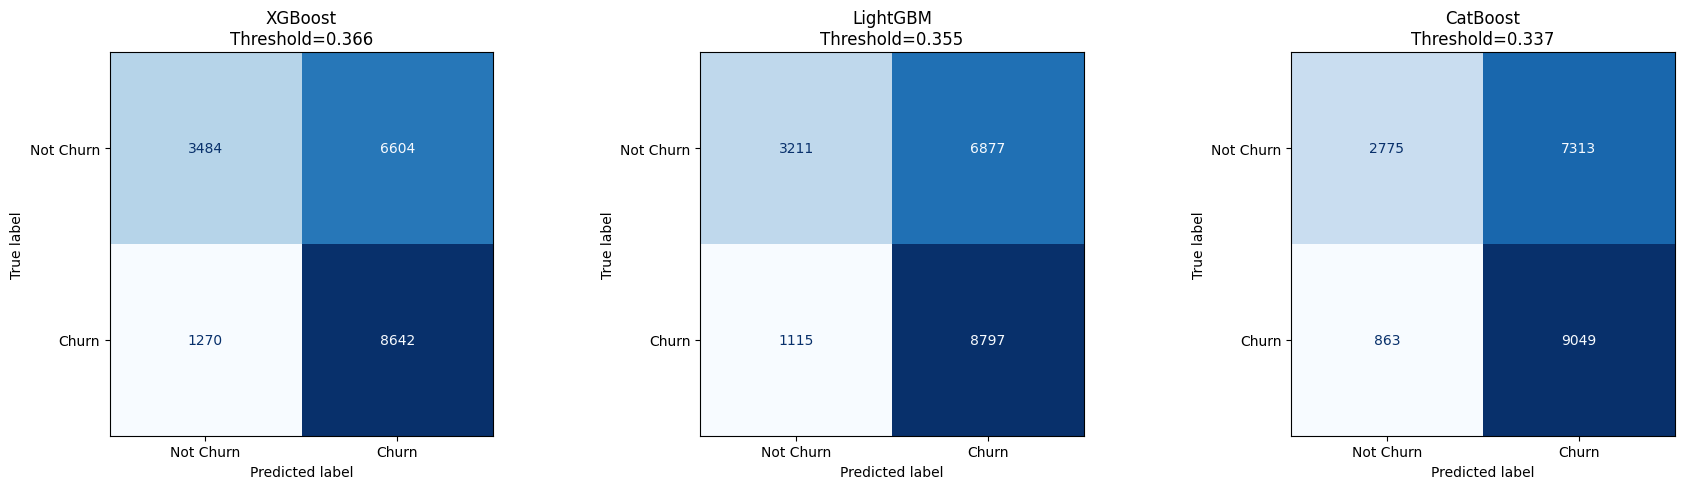


====== Comparison Table ======
             AUC  Accuracy  F1-Score  Threshold
XGBoost   0.6955    0.6063    0.6870     0.3664
LightGBM  0.6958    0.6004    0.6876     0.3554
CatBoost  0.6962    0.5912    0.6888     0.3368



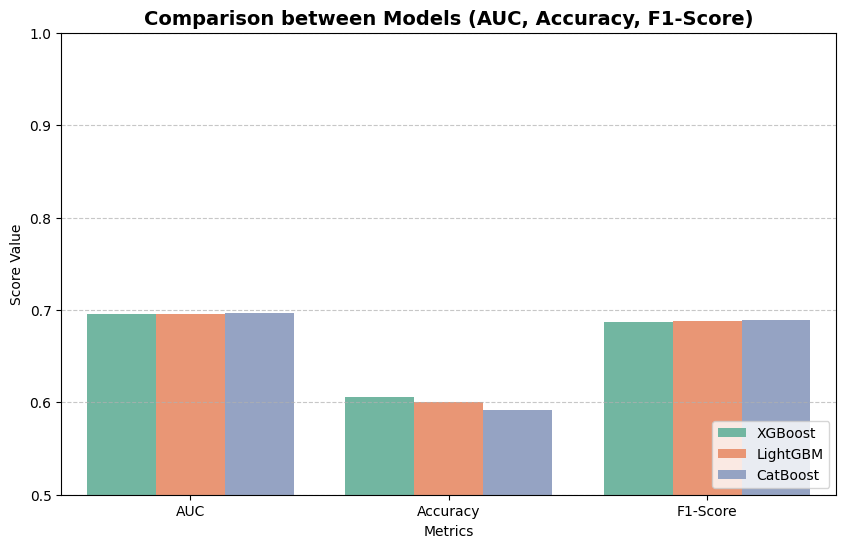

In [51]:
results = {}

models_dict = {
    'XGBoost': (xgb_model, x_test_final),
    'LightGBM': (lgb_model, x_test_final),
    'CatBoost': (cb_model, x_test_cb)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (model_name, (model, X_test_data)) in enumerate(models_dict.items()):


    pred_proba = model.predict_proba(X_test_data)[:, 1]


    precision, recall, thresholds = precision_recall_curve(
        y_test,
        pred_proba
    )

    f1_scores = (
        2 * (precision[:-1] * recall[:-1])
        / (precision[:-1] + recall[:-1] + 1e-8)
    )

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]


    pred_labels = (pred_proba >= best_threshold).astype(int)

    auc = roc_auc_score(y_test, pred_proba)
    acc = accuracy_score(y_test, pred_labels)
    f1 = f1_score(y_test, pred_labels)


    results[model_name] = {
        'AUC': auc,
        'Accuracy': acc,
        'F1-Score': f1,
        'Threshold': best_threshold
    }


    print("\n" + "=" * 50)
    print(model_name)
    print("=" * 50)
    print(f"Best Threshold : {best_threshold:.4f}")
    print(f"AUC            : {auc:.4f}")
    print(f"Accuracy       : {acc:.4f}")
    print(f"F1-Score       : {f1:.4f}")


    print("\nClassification Report")
    print(classification_report(y_test, pred_labels))


    cm = confusion_matrix(y_test, pred_labels)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Not Churn', 'Churn']
    )

    disp.plot(
        ax=axes[i],
        cmap='Blues',
        colorbar=False
    )

    axes[i].set_title(
        f"{model_name}\nThreshold={best_threshold:.3f}"
    )

plt.tight_layout()
plt.show()


df_compare = pd.DataFrame(results).T

print("\n====== Comparison Table ======")
print(df_compare.round(4))
print("==============================\n")


df_plot = df_compare.drop(columns=['Threshold'])

df_compare_melted = (
    df_plot
    .reset_index()
    .melt(
        id_vars='index',
        var_name='Metric',
        value_name='Value'
    )
)

df_compare_melted.rename(
    columns={'index': 'Model'},
    inplace=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_compare_melted,
    x='Metric',
    y='Value',
    hue='Model',
    palette='Set2'
)

plt.ylim(0.5, 1.0)
plt.title(
    'Comparison between Models (AUC, Accuracy, F1-Score)',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Score Value')
plt.xlabel('Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

plt.show()

**`Although the three models achieved very similar performance, CatBoost obtained the highest ROC-AUC (0.6962), F1-Score (0.6888), and churn recall (0.91). Since the objective is to identify customers at risk of churn, maximizing recall while maintaining competitive overall performance made CatBoost the preferred model.`**

# **Business Action**

**`Predict which customers are likely to churn and rank them by risk `**

Predict Customer will stay or not using base model with threshold

Rank Customers using base model

In [52]:
cb_model=CatBoostClassifier(iterations= 961, depth= 7, learning_rate= 0.04296056846417805,
          l2_leaf_reg= 8.58334783077414,
     random_strength= 0.03982406275528633, border_count= 33,
      rsm= 0.7981194211421296, subsample= 0.8545743492260583, min_data_in_leaf= 21,allow_writing_files=False, random_seed=SEED, verbose=0)

In [53]:
x_train_cb = x_train_final.copy()
x_test_cb = x_test_final.copy()
for c in cat_cols_final:
    x_train_cb[c] = x_train_cb[c].astype(str)
    x_test_cb[c] = x_test_cb[c].astype(str)

In [54]:
cb_model.fit(x_train_cb, y_train, cat_features=cat_cols_final)

CatBoostClassifier(allow_writing_files=False, border_count=33, depth=7, iterations=961, l2_leaf_reg=8.58334783077414, learning_rate=0.04296056846417805, min_data_in_leaf=21, random_seed=42, random_strength=0.03982406275528633, rsm=0.7981194211421296, subsample=0.8545743492260583, verbose=0)

In [55]:
churn_probability = cb_model.predict_proba(x_test_cb)[:,1]

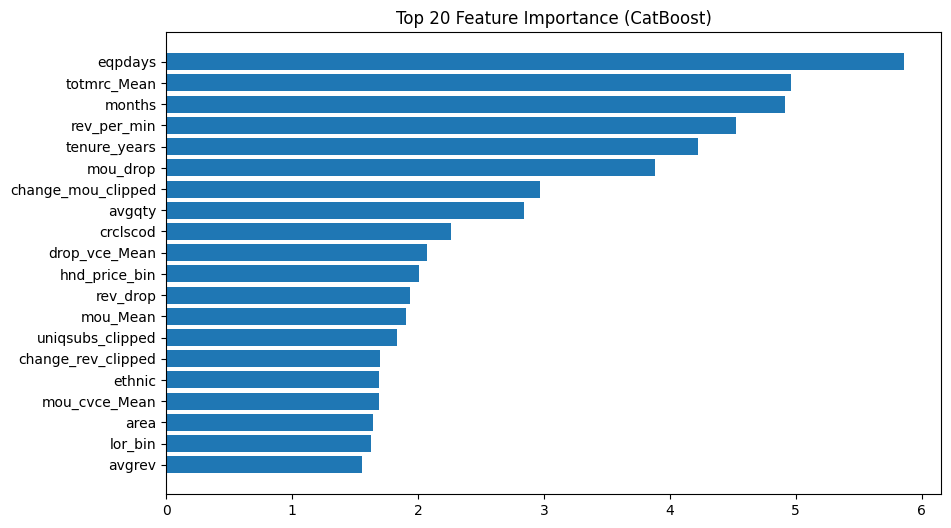

In [56]:
feature_importance = cb_model.get_feature_importance()
feature_names = x_train_cb.columns

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importance
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(fi_df["feature"][:20][::-1], fi_df["importance"][:20][::-1])
plt.title("Top 20 Feature Importance (CatBoost)")
plt.show()

In [57]:
import shap

explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(x_test_cb)

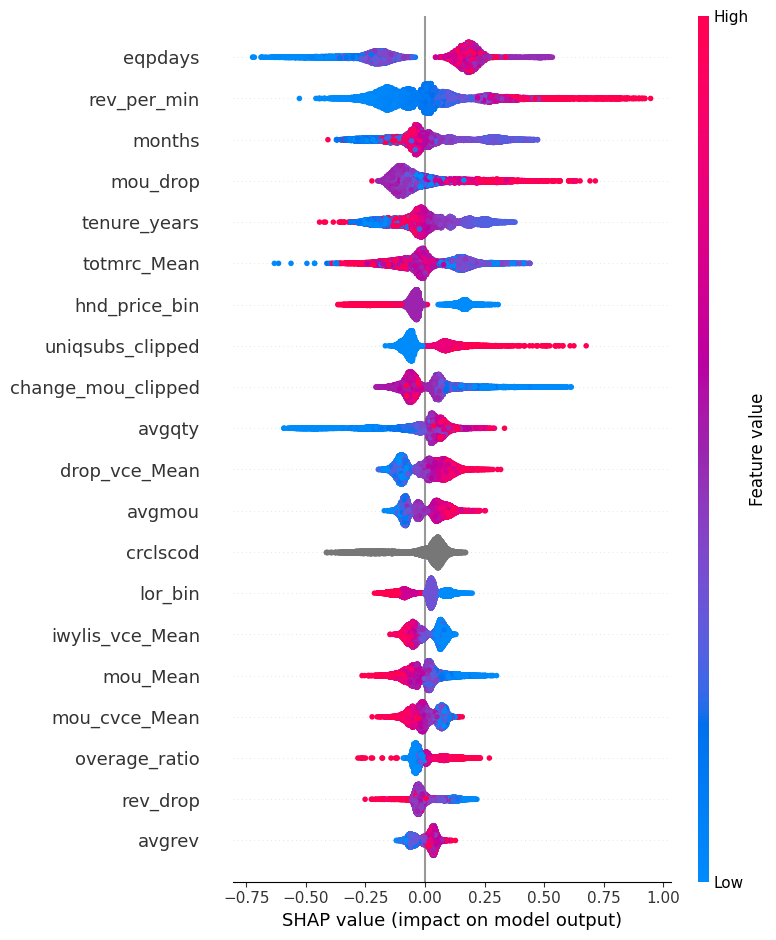

In [58]:
shap.summary_plot(shap_values, x_test_cb)

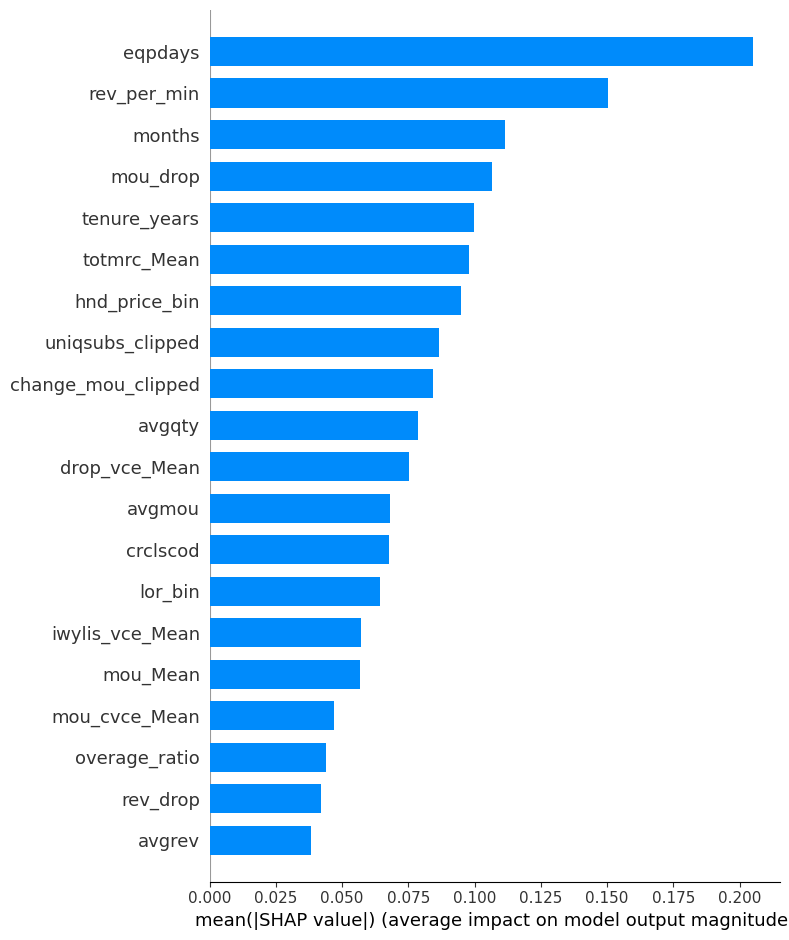

In [59]:
shap.summary_plot(shap_values, x_test_cb, plot_type="bar")

# **ٌRank Customers**

In [60]:
x_test_prob=x_test_cb.copy()

In [61]:
x_test_prob["churn_proba"] = churn_probability
x_test_prob.sort_values("churn_proba", ascending=False)

,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,...,overage_ratio,tenure_years,usage_intensity,network_issues_score,has_data_overage,is_roaming_user,income_bin,lor_bin,hnd_price_bin,churn_proba
7147,2.447063,Unknown,B,N,1.394167,1.260226,1.340444,1.199782,1.226307,1.363423,...,-0.898304,1.591278,-2.104067,-1.814651,0,0,1,3,1,0.970995
1302,1.333531,N,A,N,1.585422,1.457347,1.325798,1.323371,1.452729,1.580564,...,-0.898304,2.082586,-2.104067,-1.814651,0,0,2,1,1,0.968818
49436,1.333531,Unknown,B,N,1.002894,0.990497,1.430502,1.250381,0.939982,0.936713,...,-0.898304,0.276858,-2.104067,-1.814651,0,0,1,1,1,0.968488
57207,1.954477,Y,Unknown,Y,-0.139258,-0.230724,-0.295513,-0.459488,-0.230633,-0.138598,...,-0.898304,0.046664,-2.104067,-1.814651,0,0,2,1,2,0.968029
1625,1.954477,Unknown,A,N,1.268926,0.912471,0.236618,0.280535,0.926048,1.282509,...,-0.898304,1.818779,-2.104067,-1.814651,0,0,2,1,0,0.967057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96703,-0.592626,Unknown,A,N,-1.959960,-1.617852,-1.140787,-1.662531,-1.603566,-1.942567,...,-0.898304,-1.700381,-0.104257,-1.422466,0,0,4,3,1,0.073913
94818,-0.592626,Y,A,N,-1.674527,-1.184415,-1.214704,-1.254645,-1.173485,-1.659226,...,-0.898304,-1.237677,-0.328461,-0.698802,0,0,1,3,2,0.072304
96267,-0.592626,Unknown,E,Y,0.138823,-0.161559,-0.674794,-0.742466,-0.150629,0.146645,...,-0.898304,-1.459084,-0.526201,0.629710,0,0,2,3,1,0.065285
92996,-0.592626,Unknown,D,Y,1.006553,0.597762,0.386490,0.368948,0.609294,1.016811,...,1.232124,-1.033686,0.825716,2.172705,0,1,2,1,1,0.057783


**`Churn Prediction`**

In [62]:
threshold = 0.3368
x_test_prob["churn_pred"] = (x_test_prob["churn_proba"] > threshold).astype(int)

In [63]:
x_test_prob.head()

,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,...,tenure_years,usage_intensity,network_issues_score,has_data_overage,is_roaming_user,income_bin,lor_bin,hnd_price_bin,churn_proba,churn_pred
72528,1.333531,Unknown,Z,N,0.100993,0.640490,-0.421975,-0.470707,0.601302,0.039661,...,-0.669985,1.135212,0.690726,0,0,2,1,1,0.780411,1
61418,1.333531,Unknown,A,N,-0.737576,-0.599904,-1.005407,-1.095284,-0.612470,-0.771137,...,-1.033686,0.479756,0.204699,0,1,4,2,1,0.643767,1
76571,-0.592626,Y,D,Y,-0.256697,-0.324120,-0.466049,-0.558162,-0.308153,-0.241612,...,-1.700381,1.460995,0.803680,0,0,3,2,1,0.141013,0
23239,-0.592626,Y,Z,N,2.477269,2.106055,1.796910,1.814659,2.113128,2.488613,...,0.668448,0.991537,-0.332367,0,0,2,1,1,0.431856,1
94364,1.954477,Unknown,A,N,-0.189641,0.050469,-2.131342,-1.858710,0.040238,-0.194373,...,-1.237677,0.946475,0.482274,0,1,2,0,2,0.286057,0


In [89]:
x_test_prob['risk_segment'] = pd.cut(
    x_test_prob['churn_proba'],
    bins=[0, 0.3, 0.6, 1],
    labels=[
        'Low Risk',
        'Medium Risk',
        'High Risk'
    ]
)

In [90]:
segment_pct = (
    x_test_prob['risk_segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(segment_pct)

risk_segment
Medium Risk    58.19
High Risk      28.38
Low Risk       13.43
Name: proportion, dtype: float64


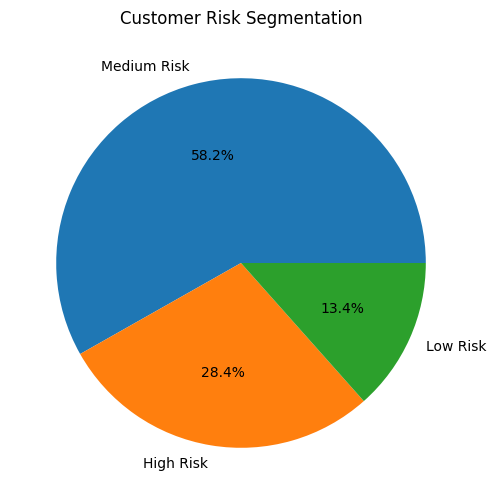

In [91]:
segment_pct = (
    x_test_prob['risk_segment']
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(6,6))
plt.pie(
    segment_pct,
    labels=segment_pct.index,
    autopct='%1.1f%%'
)

plt.title('Customer Risk Segmentation')
plt.show()

# **Decile Analysis**

In [64]:
x_test_prob["y_true"] = y_test.values

x_test_prob = x_test_prob.sort_values("churn_proba", ascending=False)

In [65]:
x_test_prob["decile"] = pd.qcut(x_test_prob["churn_proba"], 10, labels=False)

In [71]:
x_test_prob.groupby("decile").agg(
    customers=("y_true","count"),
    churn_rate=("y_true","mean"),
    churners=("y_true","sum")
)

,customers,churn_rate,churners
decile,,,
0,2000,0.1930,386
1,2000,0.3065,613
2,2000,0.3845,769
3,2000,0.4310,862
4,2000,0.4585,917
5,2000,0.5210,1042
6,2000,0.5735,1147
7,2000,0.6185,1237
8,2000,0.6815,1363


In [70]:
x_test_prob.groupby("decile")["y_true"].mean()

,y_true
decile,
0,0.1930
1,0.3065
2,0.3845
3,0.4310
4,0.4585
5,0.5210
6,0.5735
7,0.6185
8,0.6815


In [66]:
lift_table = x_test_prob.groupby("decile").agg(
    total=("y_true", "count"),
    churners=("y_true", "sum")
)

lift_table["response_rate"] = lift_table["churners"] / lift_table["total"]
lift_table["lift"] = lift_table["response_rate"] / x_test_prob["y_true"].mean()

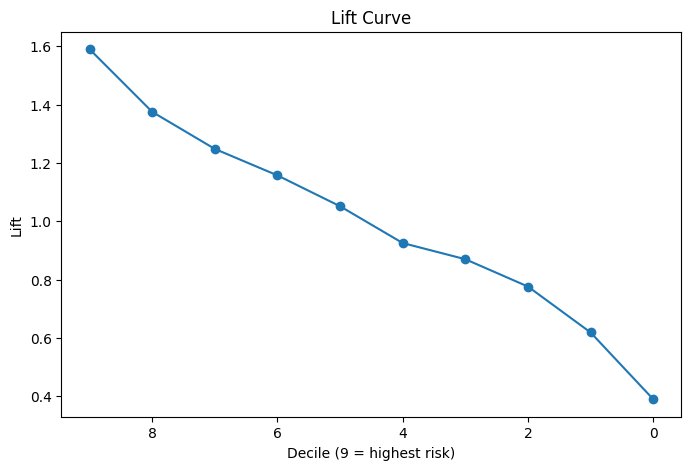

In [74]:
plt.figure(figsize=(8,5))
plt.plot(lift_table.index, lift_table["lift"], marker="o")
plt.title("Lift Curve")
plt.xlabel("Decile (9 = highest risk)")
plt.ylabel("Lift")
plt.gca().invert_xaxis()
plt.show()

In [72]:
top_decile = x_test_prob[x_test_prob["decile"] == 9]

print("Top Decile Churn Rate:", top_decile["y_true"].mean())
print("Overall Churn Rate:", x_test_prob["y_true"].mean())

Top Decile Churn Rate: 0.788
Overall Churn Rate: 0.4956


In [73]:
top_decile["y_true"].sum() / x_test_prob["y_true"].sum()

np.float64(0.15899919289749798)